In [2]:
import os, glob
from pathlib import Path

DID_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation"
DID_SHP_GUESS = os.path.join(DID_DIR, "A16-15_苏航_DID.shp")

print("DID_DIR exists:", os.path.exists(DID_DIR))
print("DID_SHP_GUESS exists:", os.path.exists(DID_SHP_GUESS))
print("DID_SHP_GUESS =", DID_SHP_GUESS)

print("\n--- SHP in DID_DIR (non-recursive) ---")
shps = glob.glob(os.path.join(DID_DIR, "*.shp"))
for p in shps:
    print(p)

print("\n--- SHP in DID_DIR (recursive) ---")
shps_r = [str(p) for p in Path(DID_DIR).rglob("*.shp")]
for p in shps_r[:50]:
    print(p)
print("Total recursive shp:", len(shps_r))

# 如果递归能找到，就把第一个拿来用
if not os.path.exists(DID_SHP_GUESS) and len(shps_r) > 0:
    print("\n>>> Using found shp instead of guess:")
    print(">>>", shps_r[0])


DID_DIR exists: True
DID_SHP_GUESS exists: False
DID_SHP_GUESS = /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_苏航_DID.shp

--- SHP in DID_DIR (non-recursive) ---
/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp

--- SHP in DID_DIR (recursive) ---
/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp
Total recursive shp: 1

>>> Using found shp instead of guess:
>>> /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp


exists DID : True /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp
exists BASE: True /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp
read DID with pyogrio failed -> ValueError('year 0 is out of range')

=== DID loaded ===
rows: 2049
crs : None
columns: ['A16_001', 'A16_002', 'A16_003', 'A16_004', 'A16_005', 'A16_006', 'A16_007', 'A16_008', 'A16_009', 'A16_010', 'geometry']

=== BASE loaded ===
rows: 171
crs : EPSG:4326
invalid DID geometries: 19 -> buffer(0) fix

=== Missing ===
POP missing ratio : 0.0
AREA missing ratio: 0.0

=== DID summary ===
Total pop: 134553144.0
Total area (km2): 21391.62
Pop quantiles: {0.0: 0.0, 0.01: 5170.36, 0.1: 6382.0, 0.5: 21943.0, 0.9: 193295.0, 0.99: 432903.9999999997, 1.0: 903346.0}
Area(km2) quantiles: {0.0: 0.0, 0.01: 0.6848, 0.1: 1.1980000000000002, 0.5: 4.56, 0.9: 29.2, 0.99: 59.407199999999946, 1.0: 113.7}
Density(pers

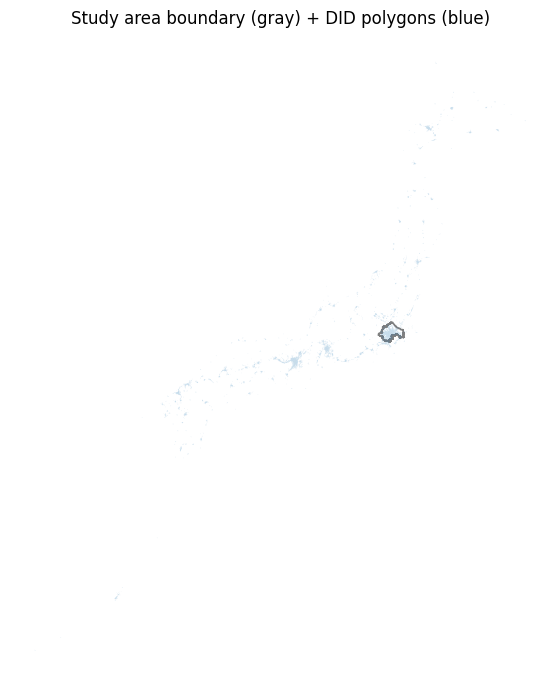


=== Coverage (area-based, sanity only) ===
base area (m2): 4016490756.7296224
intersection area (m2): 2450002451.417342
area coverage ratio (DID ∩ base)/base: 0.6099858308679954

=== DID head (key fields) ===


,A16_005,A16_006,density_person_per_km2
0,235356,22.97,10246.234219
1,238299,29.05,8203.063683
2,31589,5.40,5849.814815
3,5607,1.12,5006.250000
4,249339,30.62,8143.011104


In [4]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# =========================
# Paths
# =========================
DID_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

print("exists DID :", os.path.exists(DID_SHP), DID_SHP)
print("exists BASE:", os.path.exists(BASE_SHP), BASE_SHP)

# =========================
# Robust reader for DID (handles invalid date year=0 in A16_011)
# =========================
def read_did_robust(path: str) -> gpd.GeoDataFrame:
    """
    Try to read DID shapefile robustly:
    1) try pyogrio (often reads datetimes as strings)
    2) try fiona ignoring the problematic datetime field A16_011
    3) try fiona reading only needed fields (exclude A16_011)
    """
    # --- 1) pyogrio first (if available)
    try:
        did0 = gpd.read_file(path, engine="pyogrio")
        return did0
    except Exception as e1:
        print("read DID with pyogrio failed ->", repr(e1))

    # --- 2) fiona + ignore_fields
    try:
        did1 = gpd.read_file(path, engine="fiona", ignore_fields=["A16_011"])
        return did1
    except TypeError as e_ignore_not_supported:
        # older fiona may not support ignore_fields
        print("fiona ignore_fields not supported ->", repr(e_ignore_not_supported))
    except Exception as e2:
        print("read DID with fiona(ignore_fields) failed ->", repr(e2))

    # --- 3) fiona + columns (read only required attrs)
    # NOTE: columns must exclude A16_011; add more if you later need them.
    cols = ["A16_001", "A16_002", "A16_003", "A16_004", "A16_005", "A16_006", "A16_007", "A16_008", "A16_009", "A16_010"]
    try:
        did2 = gpd.read_file(path, engine="fiona", columns=cols)
        return did2
    except Exception as e3:
        raise RuntimeError(f"Failed to read DID shp with all methods. Last error: {e3}") from e3

# =========================
# 1) Read DID & BASE
# =========================
did = read_did_robust(DID_SHP)
base = gpd.read_file(BASE_SHP)  # base 一般没日期坑，用默认即可

print("\n=== DID loaded ===")
print("rows:", len(did))
print("crs :", did.crs)
print("columns:", list(did.columns))

print("\n=== BASE loaded ===")
print("rows:", len(base))
print("crs :", base.crs)

# CRS fallback
if did.crs is None:
    did = did.set_crs("EPSG:6668")  # JGD2011 lon/lat 兜底
    print("WARNING: DID CRS None -> set to EPSG:6668")
if base.crs is None:
    base = base.set_crs("EPSG:4326")
    print("WARNING: BASE CRS None -> set to EPSG:4326")

# Fix invalid geometries (optional but safe)
bad = (~did.is_valid).sum()
if bad > 0:
    print(f"invalid DID geometries: {bad} -> buffer(0) fix")
    did["geometry"] = did.buffer(0)

# =========================
# 2) Key fields + stats
# =========================
POP_COL = "A16_005"   # population
AREA_COL = "A16_006"  # area in km^2

if POP_COL not in did.columns or AREA_COL not in did.columns:
    raise KeyError(f"Missing required fields in DID. Need {POP_COL},{AREA_COL}. Got: {list(did.columns)}")

did[POP_COL] = pd.to_numeric(did[POP_COL], errors="coerce")
did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")
did["density_person_per_km2"] = did[POP_COL] / did[AREA_COL]

print("\n=== Missing ===")
print("POP missing ratio :", did[POP_COL].isna().mean())
print("AREA missing ratio:", did[AREA_COL].isna().mean())

print("\n=== DID summary ===")
print("Total pop:", float(np.nansum(did[POP_COL])))
print("Total area (km2):", float(np.nansum(did[AREA_COL])))

def quantiles(s):
    s = pd.Series(s).replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) == 0:
        return {}
    return s.quantile([0, 0.01, 0.1, 0.5, 0.9, 0.99, 1]).to_dict()

print("Pop quantiles:", quantiles(did[POP_COL]))
print("Area(km2) quantiles:", quantiles(did[AREA_COL]))
print("Density(person/km2) quantiles:", quantiles(did["density_person_per_km2"]))

# =========================
# 3) Plot overlay (Study boundary + DID)
# =========================
base_outline = base.dissolve()

# Align CRS for plotting
did_plot = did.to_crs(base_outline.crs) if str(did.crs) != str(base_outline.crs) else did

fig, ax = plt.subplots(figsize=(10, 7))
base_outline.boundary.plot(ax=ax, color="0.5", linewidth=1.2, zorder=1)
did_plot.plot(ax=ax, color="tab:blue", alpha=0.25, linewidth=0, zorder=2)
ax.set_title("Study area boundary (gray) + DID polygons (blue)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

# =========================
# 4) Coverage ratio (area-based sanity check)
# =========================
try:
    utm = base_outline.estimate_utm_crs()
    if utm is None:
        raise ValueError("estimate_utm_crs returned None")
except Exception as e:
    print("WARNING: estimate_utm_crs failed -> fallback to EPSG:3857. Err:", repr(e))
    utm = "EPSG:3857"

base_m = base_outline.to_crs(utm)
did_m = did_plot.to_crs(utm)

base_geom = unary_union(base_m.geometry)
did_geom  = unary_union(did_m.geometry)

base_area = float(base_geom.area)
inter_area = float(base_geom.intersection(did_geom).area)
coverage_ratio = inter_area / base_area if base_area > 0 else np.nan

print("\n=== Coverage (area-based, sanity only) ===")
print("base area (m2):", base_area)
print("intersection area (m2):", inter_area)
print("area coverage ratio (DID ∩ base)/base:", coverage_ratio)

# =========================
# 5) Head
# =========================
print("\n=== DID head (key fields) ===")
try:
    display(did[[POP_COL, AREA_COL, "density_person_per_km2"]].head())
except NameError:
    print(did[[POP_COL, AREA_COL, "density_person_per_km2"]].head())


=== Clipped DID to study area ===
DID rows (original): 2049
DID rows (intersect base): 256
Sum pop_in_base: 35756886.96781666
Sum area_in_base (attr km2): 3390.50512766875
Area coverage ratio (DID ∩ base)/base: 0.609999005377814


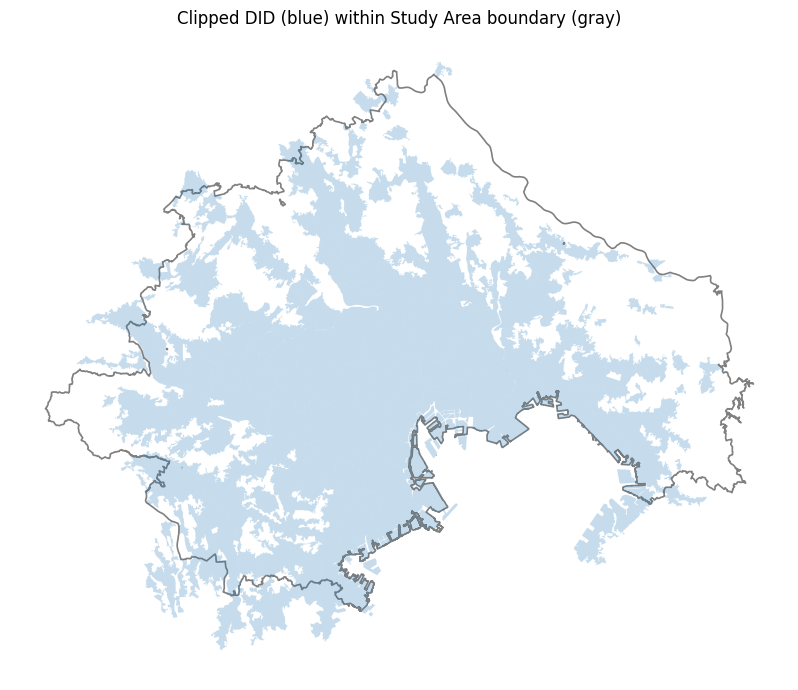

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# ---- paths
DID_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

POP_COL, AREA_COL = "A16_005", "A16_006"

# ---- read DID robustly (ignore A16_011 year=0)
did = gpd.read_file(DID_SHP, engine="fiona", ignore_fields=["A16_011"])
base = gpd.read_file(BASE_SHP)

# ---- CRS fallback
if did.crs is None:
    did = did.set_crs("EPSG:6668")  # JGD2011 lon/lat 兜底
if base.crs is None:
    base = base.set_crs("EPSG:4326")

# ---- fix invalid geoms if any
bad = (~did.is_valid).sum()
if bad > 0:
    did["geometry"] = did.buffer(0)

# ---- numeric fields
did[POP_COL]  = pd.to_numeric(did[POP_COL], errors="coerce")
did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")

# ---- dissolve study area to one geometry
base_outline = base.dissolve()

# ---- align CRS for geometry operations
did2 = did.to_crs(base_outline.crs) if str(did.crs) != str(base_outline.crs) else did.copy()

# ---- project to metric CRS for area/distance sanity
utm = base_outline.estimate_utm_crs()
if utm is None:
    utm = "EPSG:3857"
base_m = base_outline.to_crs(utm)
did_m  = did2.to_crs(utm)

base_geom = unary_union(base_m.geometry)

# ---- compute intersection area ratio per DID polygon (vectorized)
did_area = did_m.geometry.area
inter_geom = did_m.geometry.intersection(base_geom)
inter_area = inter_geom.area

ratio = np.where(did_area > 0, inter_area / did_area, 0.0)

# ---- keep only DID that intersects base
m = inter_area > 0
did_clip = did_m.loc[m].copy()
did_clip["inter_area_m2"] = inter_area[m]
did_clip["area_m2"] = did_area[m]
did_clip["ratio_in_base"] = ratio[m]

# ---- population & area inside base (area-weighted allocation)
# Note: AREA_COL is km2 attribute; we also compute area by geometry for safety.
did_clip["pop_in_base"] = did_clip[POP_COL].astype(float) * did_clip["ratio_in_base"]
did_clip["area_km2_in_base_attr"] = did_clip[AREA_COL].astype(float) * did_clip["ratio_in_base"]
did_clip["density_person_per_km2_in_base_attr"] = did_clip["pop_in_base"] / did_clip["area_km2_in_base_attr"].replace(0, np.nan)

print("=== Clipped DID to study area ===")
print("DID rows (original):", len(did_m))
print("DID rows (intersect base):", len(did_clip))
print("Sum pop_in_base:", float(did_clip["pop_in_base"].sum()))
print("Sum area_in_base (attr km2):", float(did_clip["area_km2_in_base_attr"].sum()))

# coverage ratio (area-based, sanity)
base_area = float(base_geom.area)
inter_total_area = float(did_clip["inter_area_m2"].sum())
print("Area coverage ratio (DID ∩ base)/base:", inter_total_area / base_area if base_area > 0 else np.nan)

# ---- plot (back to base CRS for display)
did_clip_plot = did_clip.to_crs(base_outline.crs)
fig, ax = plt.subplots(figsize=(10, 7))
base_outline.boundary.plot(ax=ax, color="0.5", linewidth=1.2, zorder=1)
did_clip_plot.plot(ax=ax, color="tab:blue", alpha=0.25, linewidth=0, zorder=2)
ax.set_title("Clipped DID (blue) within Study Area boundary (gray)")
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [6]:
print("DID bounds:", did.total_bounds)        # 或 did2.total_bounds / did_plot.total_bounds
print("BASE bounds:", base.total_bounds)

# 如果看到类似：
# 经度大概 120~150，纬度大概 20~50  -> OK（经纬度）
# 如果是几百万/几千万那种大数 -> CRS 可能其实是米制投影，需要重新设 CRS


DID bounds: [124.13721826  24.33113413 145.60882652  45.44649299]
BASE bounds: [139.16160367  35.40258717 140.30130789  36.10913667]


In [7]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.ops import unary_union

# ====== paths（和你之前一致）======
DID_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

POP_COL, AREA_COL = "A16_005", "A16_006"

# ====== 如果 did_clip 不在内存，自动重算一遍（与你之前的裁剪逻辑同口径）======
if "did_clip" not in globals():
    print("did_clip not found -> recomputing did_clip ...")
    did = gpd.read_file(DID_SHP, engine="fiona", ignore_fields=["A16_011"])
    base = gpd.read_file(BASE_SHP)

    if did.crs is None:
        did = did.set_crs("EPSG:6668")  # JGD2011 lon/lat 兜底
    if base.crs is None:
        base = base.set_crs("EPSG:4326")

    bad = (~did.is_valid).sum()
    if bad > 0:
        did["geometry"] = did.buffer(0)

    did[POP_COL]  = pd.to_numeric(did[POP_COL], errors="coerce")
    did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")

    base_outline = base.dissolve()
    did2 = did.to_crs(base_outline.crs) if str(did.crs) != str(base_outline.crs) else did.copy()

    utm = base_outline.estimate_utm_crs()
    if utm is None:
        utm = "EPSG:3857"

    base_m = base_outline.to_crs(utm)
    did_m  = did2.to_crs(utm)

    base_geom = unary_union(base_m.geometry)

    did_area = did_m.geometry.area
    inter_geom = did_m.geometry.intersection(base_geom)
    inter_area = inter_geom.area

    ratio = np.where(did_area > 0, inter_area / did_area, 0.0)
    m = inter_area > 0

    did_clip = did_m.loc[m].copy()
    did_clip["inter_area_m2"] = inter_area[m]
    did_clip["area_m2"] = did_area[m]
    did_clip["ratio_in_base"] = ratio[m]
    did_clip["pop_in_base"] = did_clip[POP_COL].astype(float) * did_clip["ratio_in_base"]
    did_clip["area_km2_in_base_attr"] = did_clip[AREA_COL].astype(float) * did_clip["ratio_in_base"]

    print("did_clip rows:", len(did_clip))
    print("Sum pop_in_base:", float(did_clip["pop_in_base"].sum()))

# ====== 生成“人口点”：用 representative_point() 保证落在面内 ======
did_clip = did_clip.copy()
did_clip = did_clip[did_clip["pop_in_base"] > 0].copy()

did_clip["pop_pt"] = did_clip.geometry.representative_point()
pop_gdf = gpd.GeoDataFrame(
    did_clip[["pop_in_base", "area_km2_in_base_attr"]].copy(),
    geometry=did_clip["pop_pt"],
    crs=did_clip.crs,
)

print("pop_gdf rows:", len(pop_gdf))
print("pop total:", float(pop_gdf["pop_in_base"].sum()))
print("pop CRS:", pop_gdf.crs)


pop_gdf rows: 255
pop total: 35756886.96781665
pop CRS: EPSG:32654


In [9]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union

# =========================
# Paths
# =========================
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")

BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"

DID_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
POP_COL, AREA_COL = "A16_005", "A16_006"

# =========================
# 0) Ensure pop_gdf exists (recompute if missing)
# =========================
if "pop_gdf" not in globals():
    print("pop_gdf not found -> recompute from DID (clip to base) ...")
    did = gpd.read_file(DID_SHP, engine="fiona", ignore_fields=["A16_011"])
    base = gpd.read_file(BASE_SHP)

    if did.crs is None:
        did = did.set_crs("EPSG:6668")  # JGD2011 lon/lat fallback
    if base.crs is None:
        base = base.set_crs("EPSG:4326")

    bad = (~did.is_valid).sum()
    if bad > 0:
        did["geometry"] = did.buffer(0)

    did[POP_COL]  = pd.to_numeric(did[POP_COL], errors="coerce")
    did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")

    base_outline = base.dissolve()
    did2 = did.to_crs(base_outline.crs) if str(did.crs) != str(base_outline.crs) else did.copy()

    utm0 = base_outline.estimate_utm_crs()
    if utm0 is None:
        utm0 = "EPSG:3857"

    base_m = base_outline.to_crs(utm0)
    did_m  = did2.to_crs(utm0)

    base_geom = unary_union(base_m.geometry)

    did_area = did_m.geometry.area
    inter_geom = did_m.geometry.intersection(base_geom)
    inter_area = inter_geom.area

    ratio = np.where(did_area > 0, inter_area / did_area, 0.0)
    m = inter_area > 0

    did_clip = did_m.loc[m].copy()
    did_clip["ratio_in_base"] = ratio[m]
    did_clip["pop_in_base"] = did_clip[POP_COL].astype(float) * did_clip["ratio_in_base"]
    did_clip["area_km2_in_base_attr"] = did_clip[AREA_COL].astype(float) * did_clip["ratio_in_base"]

    did_clip = did_clip[did_clip["pop_in_base"] > 0].copy()
    did_clip["pop_pt"] = did_clip.geometry.representative_point()

    pop_gdf = gpd.GeoDataFrame(
        did_clip[["pop_in_base", "area_km2_in_base_attr"]].copy(),
        geometry=did_clip["pop_pt"],
        crs=did_clip.crs,
    )

    print("pop_gdf rows:", len(pop_gdf))
    print("pop total:", float(pop_gdf["pop_in_base"].sum()))
    print("pop CRS:", pop_gdf.crs)

# =========================
# 1) Ensure parks_gdf exists (load from csv if missing)
# =========================
if "parks_gdf" not in globals():
    print("parks_gdf not found -> loading from:", OUT_TABLE_CSV)
    dfp = pd.read_csv(OUT_TABLE_CSV, encoding="utf-8-sig")

    need_cols = ["osm_id_norm","Lat","Lng","area_m2","park_class_name","land_cost_yen","annual_maint_yen","annual_benefit_yen"]
    miss = [c for c in need_cols if c not in dfp.columns]
    if miss:
        raise KeyError(f"park_payback_table.csv missing columns: {miss}\nCurrent columns={list(dfp.columns)}")

    TYPE_MAP = {
        "Block Park": "A",
        "Neighborhood Park": "B",
        "District Park": "C",
        "Comprehensive Park": "D",
        "Regional Park": "E",
    }
    dfp["abcde"] = dfp["park_class_name"].astype(str).str.strip().map(TYPE_MAP)

    parks_gdf = gpd.GeoDataFrame(
        dfp,
        geometry=gpd.points_from_xy(dfp["Lng"], dfp["Lat"]),
        crs="EPSG:4326",
    )

    print("parks rows:", len(parks_gdf))
    print("parks CRS:", parks_gdf.crs)
    print("type counts:\n", parks_gdf["abcde"].value_counts(dropna=False))

# =========================
# 2) Compute E_pop with overlap dilution (all types compete)
# =========================
RADIUS_M = 6000.0
GAMMA_AREA = 0.5  # sqrt(area)

LOGSIG = {"A": 11.7571, "B": 11.9702, "C": 12.3210, "D": 12.2487, "E": 12.7412}
BETA   = {"A": -0.4160, "B": -0.4193, "C": -0.4217, "D": -0.3829, "E": -0.4308}

# metric CRS (use study area UTM)
base_outline = gpd.read_file(BASE_SHP).dissolve()
utm = base_outline.estimate_utm_crs()
if utm is None:
    utm = "EPSG:3857"
print("Using metric CRS:", utm)

parks_m = parks_gdf.to_crs(utm)
pop_m   = pop_gdf.to_crs(utm)

park_xy = np.c_[parks_m.geometry.x.values, parks_m.geometry.y.values].astype(np.float64)
pop_xy  = np.c_[pop_m.geometry.x.values,   pop_m.geometry.y.values].astype(np.float64)
pop_w   = pop_m["pop_in_base"].values.astype(np.float64)

park_type = parks_m["abcde"].values
beta_arr = np.array([BETA.get(t, np.nan) for t in park_type], dtype=np.float64)

logsig_vals = np.array([LOGSIG.get(t, np.nan) for t in park_type], dtype=np.float64)
logsig_mean = np.nanmean(list(LOGSIG.values()))
omega = np.exp(logsig_vals - logsig_mean)

area_m2 = pd.to_numeric(parks_m["area_m2"], errors="coerce").fillna(0).values.astype(np.float64)
area_m2 = np.clip(area_m2, 1.0, None)
attr = omega * (area_m2 ** GAMMA_AREA)

# KDTree neighbors within 6km
try:
    from scipy.spatial import cKDTree
    tree = cKDTree(park_xy)
    neigh = tree.query_ball_point(pop_xy, r=RADIUS_M)
    print("Using scipy.spatial.cKDTree")
except Exception as e:
    print("scipy cKDTree not available, fallback to sklearn BallTree. Err:", repr(e))
    from sklearn.neighbors import BallTree
    tree = BallTree(park_xy, metric="euclidean")
    neigh = tree.query_radius(pop_xy, r=RADIUS_M, return_distance=False)
    neigh = [list(x) for x in neigh]
    print("Using sklearn BallTree")

E_pop = np.zeros(len(parks_m), dtype=np.float64)
covered_pop = 0.0

for c_idx, idxs in enumerate(neigh):
    if len(idxs) == 0:
        continue
    idxs = np.asarray(idxs, dtype=int)

    dx = park_xy[idxs, 0] - pop_xy[c_idx, 0]
    dy = park_xy[idxs, 1] - pop_xy[c_idx, 1]
    dist = np.sqrt(dx*dx + dy*dy)
    dist = np.maximum(dist, 1.0)

    b = beta_arr[idxs]
    a = attr[idxs]
    w = a * (dist ** b)

    sw = w.sum()
    if not np.isfinite(sw) or sw <= 0:
        continue

    s = w / sw
    contrib = pop_w[c_idx] * s

    np.add.at(E_pop, idxs, contrib)
    covered_pop += pop_w[c_idx]

parks_out = parks_gdf.copy()
parks_out["E_pop"] = E_pop
parks_out["E_pop_per_m2"] = parks_out["E_pop"] / parks_out["area_m2"].replace(0, np.nan)

print("Total pop (DID in base):", float(pop_w.sum()))
print("Total pop covered by >=1 park within 6km:", float(covered_pop))
print("Sum E_pop across parks:", float(np.nansum(E_pop)))

OUT_EPOP_CSV = os.path.join(OUT_DIR, "park_exposure_Epop_alltypes.csv")
parks_out.to_csv(OUT_EPOP_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_EPOP_CSV)

ab = parks_out[parks_out["abcde"].isin(["A","B"])].copy()
print("\nA/B E_pop summary:")
print(ab["E_pop"].describe(percentiles=[0.1,0.5,0.9,0.99]))


parks_gdf not found -> loading from: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_table.csv
parks rows: 4820
parks CRS: EPSG:4326
type counts:
 abcde
B      2186
NaN    2026
C       442
D       147
E        19
Name: count, dtype: int64
Using metric CRS: EPSG:32654
Using scipy.spatial.cKDTree
Total pop (DID in base): 35756886.96781665
Total pop covered by >=1 park within 6km: 0.0010567154487123567
Sum E_pop across parks: 0.0010567154487123565
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_exposure_Epop_alltypes.csv

A/B E_pop summary:
count    2.186000e+03
mean     6.228331e-08
std      1.147669e-06
min      0.000000e+00
10%      0.000000e+00
50%      0.000000e+00
90%      0.000000e+00
99%      0.000000e+00
max      3.581151e-05
Name: E_pop, dtype: float64


In [12]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union

# =========================
# Paths
# =========================
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")

BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
DID_SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"

POP_COL, AREA_COL = "A16_005", "A16_006"

# =========================
# 1) Load base (EPSG:4326)
# =========================
base = gpd.read_file(BASE_SHP)
if base.crs is None:
    base = base.set_crs("EPSG:4326")
base_outline = base.dissolve()

# metric CRS for area/distance
utm = base_outline.estimate_utm_crs()
if utm is None:
    utm = "EPSG:3857"
print("Using metric CRS:", utm)

# =========================
# 2) Rebuild population points in EPSG:4326 (avoid CRS confusion)
# =========================
did = gpd.read_file(DID_SHP, engine="fiona", ignore_fields=["A16_011"])
# DID CRS is None in your file; bounds are lon/lat, so set to EPSG:4326 directly (足够用于 6km 尺度)
if did.crs is None:
    did = did.set_crs("EPSG:4326", allow_override=True)

# fix invalid geometries
bad = (~did.is_valid).sum()
if bad > 0:
    did["geometry"] = did.buffer(0)

did[POP_COL]  = pd.to_numeric(did[POP_COL], errors="coerce")
did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")

# project to metric to compute intersection-area ratio
did_m  = did.to_crs(utm)
base_m = base_outline.to_crs(utm)
base_geom = unary_union(base_m.geometry)

did_area = did_m.geometry.area
inter_geom = did_m.geometry.intersection(base_geom)
inter_area = inter_geom.area

ratio = np.where(did_area > 0, inter_area / did_area, 0.0)
m = inter_area > 0

did_clip_ll = did.loc[m].copy()               # keep geometry in lon/lat
did_clip_ll["ratio_in_base"] = ratio[m]
did_clip_ll["pop_in_base"] = did_clip_ll[POP_COL].astype(float) * did_clip_ll["ratio_in_base"]
did_clip_ll["area_km2_in_base_attr"] = did_clip_ll[AREA_COL].astype(float) * did_clip_ll["ratio_in_base"]
did_clip_ll = did_clip_ll[did_clip_ll["pop_in_base"] > 0].copy()

# representative point in lon/lat (guaranteed inside polygon)
did_clip_ll["pop_pt"] = did_clip_ll.geometry.representative_point()
pop_gdf_ll = gpd.GeoDataFrame(
    did_clip_ll[["pop_in_base", "area_km2_in_base_attr"]].copy(),
    geometry=did_clip_ll["pop_pt"],
    crs="EPSG:4326",
)

print("\nPop points rebuilt:")
print("pop_gdf_ll rows:", len(pop_gdf_ll))
print("pop total:", float(pop_gdf_ll["pop_in_base"].sum()))
print("pop bounds (lon/lat):", pop_gdf_ll.total_bounds)

# =========================
# 3) Load parks points (EPSG:4326) — your coords are already correct
# =========================
dfp = pd.read_csv(OUT_TABLE_CSV, encoding="utf-8-sig")

# type mapping (more robust)
name = dfp["park_class_name"].astype(str).str.strip().str.lower()
MAP_LOWER = {
    "block park": "A",
    "neighborhood park": "B",
    "district park": "C",
    "comprehensive park": "D",
    "regional park": "E",
}
dfp["abcde"] = name.map(MAP_LOWER)

# keep original lon/lat (已验证正常)
dfp["Lng"] = pd.to_numeric(dfp["Lng"], errors="coerce")
dfp["Lat"] = pd.to_numeric(dfp["Lat"], errors="coerce")
m_ok = dfp["Lng"].between(-180, 180) & dfp["Lat"].between(-90, 90)
dfp = dfp[m_ok].copy()

parks_gdf = gpd.GeoDataFrame(
    dfp,
    geometry=gpd.points_from_xy(dfp["Lng"], dfp["Lat"]),
    crs="EPSG:4326",
)

print("\nParks loaded:")
print("parks rows:", len(parks_gdf))
print("parks bounds (lon/lat):", parks_gdf.total_bounds)
print("type counts:\n", parks_gdf["abcde"].value_counts(dropna=False).head(10))

# （可选但推荐）只保留研究区内/相交 buffer 的公园，避免远处点干扰
# 这里先做一个“在研究区 bbox 内”的轻过滤
minx, miny, maxx, maxy = base_outline.total_bounds
parks_gdf = parks_gdf[parks_gdf["Lng"].between(minx-0.2, maxx+0.2) & parks_gdf["Lat"].between(miny-0.2, maxy+0.2)].copy()
print("parks rows after bbox filter:", len(parks_gdf))

# =========================
# 4) Compute E_pop with overlap dilution (all types compete)
# =========================
RADIUS_M = 6000.0
GAMMA_AREA = 0.5

LOGSIG = {"A": 11.7571, "B": 11.9702, "C": 12.3210, "D": 12.2487, "E": 12.7412}
BETA   = {"A": -0.4160, "B": -0.4193, "C": -0.4217, "D": -0.3829, "E": -0.4308}

parks_m = parks_gdf.to_crs(utm)
pop_m   = pop_gdf_ll.to_crs(utm)

# quick sanity: meter bounds should overlap
print("\nMeter bounds check:")
print("parks_m bounds:", parks_m.total_bounds)
print("pop_m   bounds:", pop_m.total_bounds)

park_xy = np.c_[parks_m.geometry.x.values, parks_m.geometry.y.values].astype(np.float64)
pop_xy  = np.c_[pop_m.geometry.x.values,   pop_m.geometry.y.values].astype(np.float64)
pop_w   = pop_m["pop_in_base"].values.astype(np.float64)

park_type = parks_m["abcde"].values
beta_arr = np.array([BETA.get(t, np.nan) for t in park_type], dtype=np.float64)

logsig_vals = np.array([LOGSIG.get(t, np.nan) for t in park_type], dtype=np.float64)
logsig_mean = np.nanmean(list(LOGSIG.values()))
omega = np.exp(np.where(np.isfinite(logsig_vals), logsig_vals, logsig_mean) - logsig_mean)

area_m2 = pd.to_numeric(parks_m["area_m2"], errors="coerce").fillna(0).values.astype(np.float64)
area_m2 = np.clip(area_m2, 1.0, None)
attr = omega * (area_m2 ** GAMMA_AREA)

from scipy.spatial import cKDTree
tree = cKDTree(park_xy)

# debug: nearest distance distribution (should be not crazy large)
dmin, _ = tree.query(pop_xy, k=1)
print("\nNearest park distance to each pop point (m):")
print(pd.Series(dmin).describe(percentiles=[0.1,0.5,0.9,0.99]))

neigh = tree.query_ball_point(pop_xy, r=RADIUS_M)

E_pop = np.zeros(len(parks_m), dtype=np.float64)
covered_pop = 0.0
n_nonempty = 0

for c_idx, idxs in enumerate(neigh):
    if len(idxs) == 0:
        continue
    n_nonempty += 1
    idxs = np.asarray(idxs, dtype=int)

    dx = park_xy[idxs, 0] - pop_xy[c_idx, 0]
    dy = park_xy[idxs, 1] - pop_xy[c_idx, 1]
    dist = np.sqrt(dx*dx + dy*dy)
    dist = np.maximum(dist, 1.0)

    b = beta_arr[idxs]
    b = np.where(np.isfinite(b), b, BETA["B"])  # unknown type -> use B
    a = attr[idxs]

    w = a * (dist ** b)
    sw = w.sum()
    if not np.isfinite(sw) or sw <= 0:
        continue

    s = w / sw
    np.add.at(E_pop, idxs, pop_w[c_idx] * s)
    covered_pop += pop_w[c_idx]

parks_out = parks_gdf.copy()
parks_out["E_pop"] = E_pop

print("\nCoverage results:")
print("Total pop (DID in base):", float(pop_w.sum()))
print("Total pop covered by >=1 park within 6km:", float(covered_pop))
print("Share covered:", float(covered_pop / pop_w.sum()))
print("pop points with >=1 park within 6km:", n_nonempty, "/", len(pop_w))
print("Sum E_pop across parks:", float(np.nansum(E_pop)))

OUT_EPOP_CSV = os.path.join(OUT_DIR, "park_exposure_Epop_alltypes.csv")
parks_out.to_csv(OUT_EPOP_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_EPOP_CSV)

print("\nA/B E_pop summary:")
print(parks_out.loc[parks_out["abcde"].isin(["A","B"]), "E_pop"].describe(percentiles=[0.1,0.5,0.9,0.99]))


Using metric CRS: EPSG:32654

Pop points rebuilt:
pop_gdf_ll rows: 255
pop total: 35756886.96781665
pop bounds (lon/lat): [139.22769277  35.3902008  140.24594791  36.11007277]

Parks loaded:
parks rows: 4820
parks bounds (lon/lat): [139.26891256  35.41394663 140.24734819  36.10071699]
type counts:
 abcde
B      2186
NaN    2026
C       442
D       147
E        19
Name: count, dtype: int64
parks rows after bbox filter: 4820

Meter bounds check:
parks_m bounds: [ 343291.89336212 3919773.19975858  431919.68279383 3995872.11726993]
pop_m   bounds: [ 339718.73096408 3917407.17275609  431804.24825968 3996829.36423616]

Nearest park distance to each pop point (m):
count     255.000000
mean      746.002600
std      1003.446304
min        28.243829
10%       123.342291
50%       439.797878
90%      1597.213962
99%      4815.972282
max      7933.270795
dtype: float64

Coverage results:
Total pop (DID in base): 35756886.96781665
Total pop covered by >=1 park within 6km: 35756886.96721138
Share co

In [13]:
import numpy as np
import pandas as pd

# pop_w / tree / pop_xy 应该已经在上一个 cell 里存在
dmin, _ = tree.query(pop_xy, k=1)
within6 = (dmin <= 6000.0)

covered_pop_w = float(np.sum(pop_w[within6]))
total_pop_w   = float(np.sum(pop_w))

print("Nearest distance (m) summary:")
print(pd.Series(dmin).describe(percentiles=[0.1,0.5,0.9,0.99]))

print("\nCoverage within 6km (pop-weighted):")
print("covered_pop =", covered_pop_w)
print("total_pop   =", total_pop_w)
print("share       =", covered_pop_w / total_pop_w)

# 如果你还想看“有多少个DID人口点”被覆盖（不加权）
print("\nCoverage within 6km (point count):")
print("covered points:", int(within6.sum()), "/", len(within6), "=", float(within6.mean()))


Nearest distance (m) summary:
count     255.000000
mean      746.002600
std      1003.446304
min        28.243829
10%       123.342291
50%       439.797878
90%      1597.213962
99%      4815.972282
max      7933.270795
dtype: float64

Coverage within 6km (pop-weighted):
covered_pop = 35756886.96721138
total_pop   = 35756886.96781665
share       = 0.9999999999830727

Coverage within 6km (point count):
covered points: 253 / 255 = 0.9921568627450981


In [14]:
import pandas as pd
import numpy as np

# dfp 来自 park_payback_table.csv（如果没有就重新读）
if "dfp" not in globals():
    import os
    OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
    OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")
    dfp = pd.read_csv(OUT_TABLE_CSV, encoding="utf-8-sig")

s_raw = dfp["park_class_name"].astype(str).str.strip()
s = s_raw.str.lower()

def classify_one(raw, low):
    # 英文关键词
    if "block" in low: return "A"
    if "neigh" in low: return "B"
    if "district" in low: return "C"
    if "comprehensive" in low: return "D"
    if "regional" in low: return "E"
    # 日文关键词（很常见）
    if "街区" in raw or "街区公園" in raw: return "A"
    if "近隣" in raw or "近隣公園" in raw: return "B"
    if "地区" in raw or "地区公園" in raw: return "C"
    if "総合" in raw or "総合公園" in raw: return "D"
    if "広域" in raw or "広域公園" in raw: return "E"
    return np.nan

abc = [classify_one(r, l) for r, l in zip(s_raw.values, s.values)]
dfp["abcde_fix"] = abc

print("type counts (fixed):\n", pd.Series(dfp["abcde_fix"]).value_counts(dropna=False))

# 看看仍然无法识别的前 30 个类别名字（用于你最后一次补 mapping）
unknown = dfp.loc[pd.isna(dfp["abcde_fix"]), "park_class_name"].astype(str).str.strip()
print("\nUnknown park_class_name top 30:")
print(unknown.value_counts().head(30))


type counts (fixed):
 abcde_fix
B    2186
A    2026
C     442
D     147
E      19
Name: count, dtype: int64

Unknown park_class_name top 30:
Series([], Name: count, dtype: int64)


In [15]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union
from scipy.spatial import cKDTree

# =========================
# Paths
# =========================
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
OUT_TABLE_CSV = os.path.join(OUT_DIR, "park_payback_table.csv")

BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
DID_SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
POP_COL, AREA_COL = "A16_005", "A16_006"

# =========================
# 0) metric CRS (UTM)
# =========================
base = gpd.read_file(BASE_SHP)
if base.crs is None:
    base = base.set_crs("EPSG:4326")
base_outline = base.dissolve()
utm = base_outline.estimate_utm_crs() or "EPSG:3857"
print("Using metric CRS:", utm)

# =========================
# 1) rebuild pop points (EPSG:4326 -> UTM)
# =========================
did = gpd.read_file(DID_SHP, engine="fiona", ignore_fields=["A16_011"])
if did.crs is None:
    # 你 bounds 已经验证是经纬度，所以这里直接当 EPSG:4326 用即可（后面统一投影到UTM算6km）
    did = did.set_crs("EPSG:4326", allow_override=True)

bad = (~did.is_valid).sum()
if bad > 0:
    did["geometry"] = did.buffer(0)

did[POP_COL]  = pd.to_numeric(did[POP_COL], errors="coerce")
did[AREA_COL] = pd.to_numeric(did[AREA_COL], errors="coerce")

did_m  = did.to_crs(utm)
base_m = base_outline.to_crs(utm)
base_geom = unary_union(base_m.geometry)

did_area = did_m.geometry.area
inter_area = did_m.geometry.intersection(base_geom).area
ratio = np.where(did_area > 0, inter_area / did_area, 0.0)

m = inter_area > 0
did_clip_ll = did.loc[m].copy()
did_clip_ll["pop_in_base"] = did_clip_ll[POP_COL].astype(float) * ratio[m]
did_clip_ll = did_clip_ll[did_clip_ll["pop_in_base"] > 0].copy()

did_clip_ll["pop_pt"] = did_clip_ll.geometry.representative_point()
pop_gdf_ll = gpd.GeoDataFrame(
    did_clip_ll[["pop_in_base"]].copy(),
    geometry=did_clip_ll["pop_pt"],
    crs="EPSG:4326",
)

print("pop points:", len(pop_gdf_ll), "| pop total:", float(pop_gdf_ll["pop_in_base"].sum()))

# =========================
# 2) load parks + make abcde_fix
# =========================
dfp = pd.read_csv(OUT_TABLE_CSV, encoding="utf-8-sig")
dfp["Lng"] = pd.to_numeric(dfp["Lng"], errors="coerce")
dfp["Lat"] = pd.to_numeric(dfp["Lat"], errors="coerce")
dfp = dfp[dfp["Lng"].between(-180, 180) & dfp["Lat"].between(-90, 90)].copy()

s_raw = dfp["park_class_name"].astype(str).str.strip()
s = s_raw.str.lower()

def classify_one(raw, low):
    if "block" in low: return "A"
    if "neigh" in low: return "B"
    if "district" in low: return "C"
    if "comprehensive" in low: return "D"
    if "regional" in low: return "E"
    if "街区" in raw or "街区公園" in raw: return "A"
    if "近隣" in raw or "近隣公園" in raw: return "B"
    if "地区" in raw or "地区公園" in raw: return "C"
    if "総合" in raw or "総合公園" in raw: return "D"
    if "広域" in raw or "広域公園" in raw: return "E"
    return np.nan

dfp["abcde"] = [classify_one(r, l) for r, l in zip(s_raw.values, s.values)]
print("type counts:\n", dfp["abcde"].value_counts(dropna=False))

parks_gdf = gpd.GeoDataFrame(
    dfp,
    geometry=gpd.points_from_xy(dfp["Lng"], dfp["Lat"]),
    crs="EPSG:4326",
)

# =========================
# 3) compute E_pop (all types compete; 6km; overlap dilution)
# =========================
RADIUS_M = 6000.0
GAMMA_AREA = 0.5  # 吸引力中的面积指数：0.5=按 sqrt(area)

LOGSIG = {"A": 11.7571, "B": 11.9702, "C": 12.3210, "D": 12.2487, "E": 12.7412}
BETA   = {"A": -0.4160, "B": -0.4193, "C": -0.4217, "D": -0.3829, "E": -0.4308}

parks_m = parks_gdf.to_crs(utm)
pop_m   = pop_gdf_ll.to_crs(utm)

park_xy = np.c_[parks_m.geometry.x.values, parks_m.geometry.y.values].astype(np.float64)
pop_xy  = np.c_[pop_m.geometry.x.values,   pop_m.geometry.y.values].astype(np.float64)
pop_w   = pop_m["pop_in_base"].values.astype(np.float64)

# beta / omega / attr
park_type = parks_m["abcde"].values
beta_arr = np.array([BETA.get(t, np.nan) for t in park_type], dtype=np.float64)
beta_arr = np.where(np.isfinite(beta_arr), beta_arr, BETA["B"])  # 不认识的类型 -> 按B保守处理

logsig_vals = np.array([LOGSIG.get(t, np.nan) for t in park_type], dtype=np.float64)
logsig_mean = np.nanmean(list(LOGSIG.values()))
omega = np.exp(np.where(np.isfinite(logsig_vals), logsig_vals, logsig_mean) - logsig_mean)

area_m2 = pd.to_numeric(parks_m["area_m2"], errors="coerce").fillna(0).values.astype(np.float64)
area_m2 = np.clip(area_m2, 1.0, None)
attr = omega * (area_m2 ** GAMMA_AREA)

tree = cKDTree(park_xy)

# 先输出最近距离 sanity（你刚才已验证，但这里保留）
dmin, _ = tree.query(pop_xy, k=1)
print("\nNearest park distance (m) quantiles:",
      pd.Series(dmin).quantile([0,0.1,0.5,0.9,0.99,1]).to_dict())

neigh = tree.query_ball_point(pop_xy, r=RADIUS_M)

E_pop = np.zeros(len(parks_m), dtype=np.float64)
covered_pop = 0.0
n_nonempty = 0

for c_idx, idxs in enumerate(neigh):
    if len(idxs) == 0:
        continue
    n_nonempty += 1
    idxs = np.asarray(idxs, dtype=int)

    dx = park_xy[idxs, 0] - pop_xy[c_idx, 0]
    dy = park_xy[idxs, 1] - pop_xy[c_idx, 1]
    dist = np.sqrt(dx*dx + dy*dy)
    dist = np.maximum(dist, 1.0)

    w = attr[idxs] * (dist ** beta_arr[idxs])
    sw = w.sum()
    if not np.isfinite(sw) or sw <= 0:
        continue

    s_share = w / sw
    np.add.at(E_pop, idxs, pop_w[c_idx] * s_share)
    covered_pop += pop_w[c_idx]

parks_out = parks_gdf.copy()
parks_out["E_pop"] = E_pop

print("\nCoverage within 6km (pop-weighted):")
print("covered_pop =", float(covered_pop))
print("total_pop   =", float(pop_w.sum()))
print("share       =", float(covered_pop / pop_w.sum()))
print("covered pop-points:", n_nonempty, "/", len(pop_w))
print("Sum E_pop across parks:", float(np.nansum(E_pop)))

OUT_EPOP_CSV = os.path.join(OUT_DIR, "park_exposure_Epop_alltypes.csv")
parks_out.to_csv(OUT_EPOP_CSV, index=False, encoding="utf-8-sig")
print("Saved:", OUT_EPOP_CSV)

print("\nA/B E_pop summary:")
print(parks_out.loc[parks_out["abcde"].isin(["A","B"]), "E_pop"].describe(percentiles=[0.1,0.5,0.9,0.99]))


Using metric CRS: EPSG:32654
pop points: 255 | pop total: 35756886.96781665
type counts:
 abcde
B    2186
A    2026
C     442
D     147
E      19
Name: count, dtype: int64

Nearest park distance (m) quantiles: {0.0: 28.24382862383392, 0.1: 123.3422911826683, 0.5: 439.7978778379503, 0.9: 1597.213961730346, 0.99: 4815.972281637773, 1.0: 7933.270794825358}

Coverage within 6km (pop-weighted):
covered_pop = 35756886.96721138
total_pop   = 35756886.96781665
share       = 0.9999999999830727
covered pop-points: 253 / 255
Sum E_pop across parks: 35756886.96721138
Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_exposure_Epop_alltypes.csv

A/B E_pop summary:
count     4212.000000
mean      4036.827946
std       3302.449224
min          0.000019
10%       1262.706591
50%       3139.671596
90%       7663.396338
99%      16332.394834
max      45269.493323
Name: E_pop, dtype: float64


In [17]:
import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ab = parks_out.loc[parks_out["abcde"].isin(["A","B"]), "E_pop"].copy()
print(ab.describe(percentiles=[0.01,0.1,0.25,0.5,0.75,0.9,0.99,0.999]))


count     4212.000000
mean      4036.827946
std       3302.449224
min          0.000019
1%         633.349791
10%       1262.706591
25%       1969.749281
50%       3139.671596
75%       5057.495405
90%       7663.396338
99%      16332.394834
99.9%    30730.186594
max      45269.493323
Name: E_pop, dtype: float64


In [19]:
import numpy as np
import pandas as pd

d = parks_out.copy()

ycol = "payback_years" if "payback_years" in d.columns else "payback_hat_years"
print("Using y =", ycol)

d["land_price_yen_per_m2"] = d["land_cost_yen"] / d["area_m2"].replace(0, np.nan)
d["maint_yen_per_m2"] = d["annual_maint_yen"] / d["area_m2"].replace(0, np.nan)

X_cols = ["land_price_yen_per_m2", "area_m2", "E_pop", "maint_yen_per_m2"]

d_ab = d[d["abcde"].isin(["A","B"])].copy()
d_ab[ycol] = pd.to_numeric(d_ab[ycol], errors="coerce")
m = np.isfinite(d_ab[ycol]) & (d_ab[ycol] > 0)
d_ab = d_ab[m].copy()

for c in X_cols:
    d_ab[c] = pd.to_numeric(d_ab[c], errors="coerce")
    d_ab[f"ln_{c}"] = np.log(d_ab[c].clip(lower=1e-9))
d_ab["ln_y"] = np.log(d_ab[ycol].clip(lower=1e-9))

def ols_numpy(X, y):
    n = X.shape[0]
    X1 = np.c_[np.ones(n), X]
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    y_hat = X1 @ beta
    resid = y - y_hat
    ssr = np.sum(resid**2)
    sst = np.sum((y - y.mean())**2)
    r2 = 1 - ssr/sst if sst > 0 else np.nan

    k1 = X1.shape[1]
    dof = max(n - k1, 1)
    sigma2 = ssr / dof
    XtX_inv = np.linalg.inv(X1.T @ X1)
    se = np.sqrt(np.diag(sigma2 * XtX_inv))
    return beta, se, r2, n

def fit_one(t):
    sub = d_ab[d_ab["abcde"] == t].dropna(subset=[f"ln_{c}" for c in X_cols] + ["ln_y"]).copy()
    if len(sub) < 200:
        print(f"\nType {t}: too few samples =", len(sub))
        return None

    X = sub[[f"ln_{c}" for c in X_cols]].values
    y = sub["ln_y"].values
    beta, se, r2, n = ols_numpy(X, y)

    print(f"\n=== Type {t} log-linear OLS (numpy) ===")
    print("n =", n, "| R2 =", float(r2))
    print("ln(T) = a + Σ b_j ln(x_j)")
    print(f"a = {beta[0]:.6f}  (se={se[0]:.6f})")
    for j, col in enumerate(X_cols, start=1):
        print(f"b_{col} = {beta[j]:.6f}  (se={se[j]:.6f})")

    A0 = float(np.exp(beta[0]))
    print("\nMultiplicative form:")
    print(f"T ≈ {A0:.6g}"
          f" * land_price^{beta[1]:.4f}"
          f" * area^{beta[2]:.4f}"
          f" * E_pop^{beta[3]:.4f}"
          f" * maint^{beta[4]:.4f}")

    return beta, r2, n

betaA = fit_one("A")
betaB = fit_one("B")


Using y = payback_years

=== Type A log-linear OLS (numpy) ===
n = 2014 | R2 = 0.008278695413028614
ln(T) = a + Σ b_j ln(x_j)
a = 4.432687  (se=1.173166)
b_land_price_yen_per_m2 = 0.120915  (se=0.031903)
b_area_m2 = -0.002046  (se=0.089668)
b_E_pop = -0.105530  (se=0.048944)
b_maint_yen_per_m2 = -0.204293  (se=0.165108)

Multiplicative form:
T ≈ 84.1572 * land_price^0.1209 * area^-0.0020 * E_pop^-0.1055 * maint^-0.2043

=== Type B log-linear OLS (numpy) ===
n = 2163 | R2 = 0.043583645827170114
ln(T) = a + Σ b_j ln(x_j)
a = 1.583326  (se=0.665308)
b_land_price_yen_per_m2 = 0.193706  (se=0.029429)
b_area_m2 = 0.319509  (se=0.042710)
b_E_pop = -0.140359  (se=0.043741)
b_maint_yen_per_m2 = -0.239776  (se=0.088280)

Multiplicative form:
T ≈ 4.87113 * land_price^0.1937 * area^0.3195 * E_pop^-0.1404 * maint^-0.2398


In [21]:
import os
import numpy as np
import pandas as pd

OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
OUT_CSV = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear.csv")

PAYBACK_HORIZON = 50.0
EPS = 1e-9

d = parks_out.copy()

# ---- 基础变量
d["land_price_yen_per_m2"] = d["land_cost_yen"] / d["area_m2"].replace(0, np.nan)
d["maint_yen_per_m2"]      = d["annual_maint_yen"] / d["area_m2"].replace(0, np.nan)

X_cols = ["land_price_yen_per_m2", "area_m2", "E_pop", "maint_yen_per_m2"]
y_col  = "annual_benefit_yen"
y_pay  = "payback_years" if "payback_years" in d.columns else None

for c in X_cols + [y_col, "annual_maint_yen", "land_cost_yen", "area_m2", "E_pop"]:
    d[c] = pd.to_numeric(d[c], errors="coerce")

def ols_numpy(X, y):
    n = X.shape[0]
    X1 = np.c_[np.ones(n), X]
    beta, *_ = np.linalg.lstsq(X1, y, rcond=None)
    yhat = X1 @ beta
    resid = y - yhat
    ssr = float(np.sum(resid**2))
    sst = float(np.sum((y - y.mean())**2))
    r2 = 1 - ssr/sst if sst > 0 else np.nan
    return beta, resid, r2, n

def fit_with_smearing(type_char):
    sub = d[d["abcde"] == type_char].copy()

    m = np.isfinite(sub[y_col]) & (sub[y_col] > 0)
    for c in X_cols:
        m &= np.isfinite(sub[c]) & (sub[c] > 0)

    sub = sub[m].copy()
    if len(sub) < 200:
        print(f"Type {type_char}: too few samples = {len(sub)}")
        return None

    y = np.log(sub[y_col].clip(lower=EPS)).values
    X = np.column_stack([np.log(sub[c].clip(lower=EPS)).values for c in X_cols])

    beta, resid, r2, n = ols_numpy(X, y)
    smear = float(np.mean(np.exp(resid)))  # Duan smearing

    print(f"\n=== Type {type_char} benefit model + smearing ===")
    print("n =", n, "| R2 =", float(r2))
    print("smearing S =", smear)
    print("ln(benefit) = a + Σ b ln(x)")
    print("a =", float(beta[0]))
    for j, col in enumerate(X_cols, start=1):
        print(f"b_{col} =", float(beta[j]))

    A0 = float(np.exp(beta[0]) * smear)
    print("\nMultiplicative (smear-corrected) form:")
    print(f"benefit_hat ≈ {A0:.6g}"
          f" * land_price^{beta[1]:.4f}"
          f" * area^{beta[2]:.4f}"
          f" * E_pop^{beta[3]:.4f}"
          f" * maint^{beta[4]:.4f}")

    return beta, smear

def predict_benefit_smear(type_char, beta, smear):
    idx = (d["abcde"] == type_char)
    sub = d.loc[idx, :].copy()

    m = np.ones(len(sub), dtype=bool)
    for c in X_cols:
        m &= np.isfinite(sub[c].values) & (sub[c].values > 0)

    Xp = np.column_stack([np.log(sub.loc[m, c].clip(lower=EPS)).values for c in X_cols])
    ln_hat = beta[0] + Xp @ beta[1:]
    bhat = np.exp(ln_hat) * smear

    out = np.full(len(sub), np.nan, dtype=float)
    out[m] = bhat
    return idx, out

# ---- Fit
resA = fit_with_smearing("A")
resB = fit_with_smearing("B")

# ---- Predict benefit
d["benefit_hat_2step_smear_yen"] = np.nan
if resA is not None:
    betaA, smearA = resA
    idxA, outA = predict_benefit_smear("A", betaA, smearA)
    d.loc[idxA, "benefit_hat_2step_smear_yen"] = outA
if resB is not None:
    betaB, smearB = resB
    idxB, outB = predict_benefit_smear("B", betaB, smearB)
    d.loc[idxB, "benefit_hat_2step_smear_yen"] = outB

# ---- Step2 payback
net_hat = d["benefit_hat_2step_smear_yen"] - d["annual_maint_yen"]
d["payback_hat_2step_smear_years"] = np.where(
    d["abcde"].isin(["A","B"]) & np.isfinite(net_hat) & (net_hat > 0) & np.isfinite(d["land_cost_yen"]),
    d["land_cost_yen"] / net_hat,
    np.nan
)

ab = d[d["abcde"].isin(["A","B"])].copy()
ab.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_CSV)

print("\n=== Predicted payback (smear-corrected) summary (A/B) ===")
print(ab["payback_hat_2step_smear_years"].describe(percentiles=[0.1,0.5,0.9,0.99]))

m_valid = np.isfinite(ab["payback_hat_2step_smear_years"])
print("\nvalid n:", int(m_valid.sum()), "/", len(ab))
if m_valid.any():
    print("<=50 share (pred):", float((ab.loc[m_valid, "payback_hat_2step_smear_years"] <= PAYBACK_HORIZON).mean()))

# ---- Compare with observed payback, if available
if y_pay is not None and y_pay in ab.columns:
    ab[y_pay] = pd.to_numeric(ab[y_pay], errors="coerce")
    m_obs = np.isfinite(ab[y_pay]) & (ab[y_pay] > 0)
    print("\n=== Observed payback summary (A/B) ===")
    print(ab.loc[m_obs, y_pay].describe(percentiles=[0.1,0.5,0.9,0.99]))
    if m_obs.any():
        print("<=50 share (obs):", float((ab.loc[m_obs, y_pay] <= PAYBACK_HORIZON).mean()))

# ---- Optional: bias check benefit level (median ratio)
m2 = np.isfinite(ab["benefit_hat_2step_smear_yen"]) & (ab[y_col] > 0)
if m2.any():
    ratio = (ab.loc[m2, "benefit_hat_2step_smear_yen"] / ab.loc[m2, y_col]).replace([np.inf, -np.inf], np.nan).dropna()
    print("\nMedian(b_hat / b_obs) =", float(ratio.median()))
    print("P10/P90(b_hat / b_obs) =", float(ratio.quantile(0.1)), "/", float(ratio.quantile(0.9)))



=== Type A benefit model + smearing ===
n = 2026 | R2 = 0.3640483206118482
smearing S = 1.7140405065483868
ln(benefit) = a + Σ b ln(x)
a = -3.5057897551345993
b_land_price_yen_per_m2 = 0.8123162063057531
b_area_m2 = 0.9646576847394284
b_E_pop = 0.10729039801485121
b_maint_yen_per_m2 = 0.2502979465109065

Multiplicative (smear-corrected) form:
benefit_hat ≈ 0.0514607 * land_price^0.8123 * area^0.9647 * E_pop^0.1073 * maint^0.2503

=== Type B benefit model + smearing ===
n = 2186 | R2 = 0.42935245906433395
smearing S = 1.5726997170833297
ln(benefit) = a + Σ b ln(x)
a = -1.247133336706259
b_land_price_yen_per_m2 = 0.7719228968398684
b_area_m2 = 0.7120351974772099
b_E_pop = 0.09901200893262105
b_maint_yen_per_m2 = 0.2884708133568651

Multiplicative (smear-corrected) form:
benefit_hat ≈ 0.45188 * land_price^0.7719 * area^0.7120 * E_pop^0.0990 * maint^0.2885

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_result3_AB_twostep_payback_hat_smear.csv

=== Predic

In [23]:
import os
import numpy as np
import pandas as pd

OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
IN_CSV  = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear.csv")
OUT_CSV = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear_paybackcal.csv")

H = 50.0  # horizon
EPS = 1e-12

ab = pd.read_csv(IN_CSV, encoding="utf-8-sig")

need = ["abcde","payback_years","benefit_hat_2step_smear_yen","annual_maint_yen","land_cost_yen"]
miss = [c for c in need if c not in ab.columns]
if miss:
    raise KeyError(f"Missing columns in {IN_CSV}: {miss}")

for c in ["payback_years","benefit_hat_2step_smear_yen","annual_maint_yen","land_cost_yen"]:
    ab[c] = pd.to_numeric(ab[c], errors="coerce")

# 固定样本：必须有观测 payback、也必须有构造预测 payback 的必要变量
base_mask = (
    ab["abcde"].isin(["A","B"]) &
    np.isfinite(ab["payback_years"]) & (ab["payback_years"] > 0) &
    np.isfinite(ab["benefit_hat_2step_smear_yen"]) & (ab["benefit_hat_2step_smear_yen"] > 0) &
    np.isfinite(ab["annual_maint_yen"]) &
    np.isfinite(ab["land_cost_yen"]) & (ab["land_cost_yen"] > 0)
)

def pred_share_leq50(sub_df, s):
    """用缩放系数 s 计算预测 payback<=50 的比例（net<=0 视为 inf，即一定 >50），样本集合不随 s 改变"""
    b = sub_df["benefit_hat_2step_smear_yen"].values
    m = sub_df["annual_maint_yen"].values
    lc = sub_df["land_cost_yen"].values

    net = s * b - m
    T = np.full_like(net, np.inf, dtype=float)
    ok = net > EPS
    T[ok] = lc[ok] / net[ok]
    return float(np.mean(T <= H))

def find_s_for_target(sub_df, target, s_lo=0.05, s_hi=5.0, iters=50):
    """
    二分法找 s，使 share<=50 接近 target
    share 随 s 单调递增（收益越大→回本越快→<=50越多）
    """
    # 先检查端点
    f_lo = pred_share_leq50(sub_df, s_lo)
    f_hi = pred_share_leq50(sub_df, s_hi)

    # 如果目标超出可达范围，就夹在端点
    if target <= f_lo:
        return s_lo, f_lo, f_hi
    if target >= f_hi:
        return s_hi, f_lo, f_hi

    lo, hi = s_lo, s_hi
    for _ in range(iters):
        mid = (lo + hi) / 2.0
        f_mid = pred_share_leq50(sub_df, mid)
        if f_mid < target:
            lo = mid
        else:
            hi = mid
    s_star = (lo + hi) / 2.0
    return s_star, f_lo, f_hi

# ---- 分类型校准
scales = {}
for t in ["A","B"]:
    sub = ab[base_mask & (ab["abcde"] == t)].copy()
    obs_share = float(np.mean(sub["payback_years"].values <= H))
    s_star, f_lo, f_hi = find_s_for_target(sub, obs_share)

    pred_star = pred_share_leq50(sub, s_star)
    scales[t] = s_star

    print(f"\nType {t}:")
    print("n =", len(sub))
    print("obs <=50 share =", obs_share)
    print("pred <=50 share @s_lo =", f_lo, "| @s_hi =", f_hi)
    print("calibrated s =", s_star)
    print("pred <=50 share @s* =", pred_star)

# ---- 生成校准后的预测 payback
ab["s_paybackcal"] = ab["abcde"].map(scales)
net = ab["s_paybackcal"] * ab["benefit_hat_2step_smear_yen"] - ab["annual_maint_yen"]
ab["payback_hat_paybackcal_years"] = np.where(net > EPS, ab["land_cost_yen"] / net, np.inf)

# ---- 汇总：整体 A/B
sub_all = ab[base_mask].copy()
obs_all = float(np.mean(sub_all["payback_years"] <= H))
pred_all = float(np.mean(sub_all["payback_hat_paybackcal_years"] <= H))

print("\n=== Overall (A+B) ===")
print("obs <=50 share =", obs_all)
print("pred <=50 share (payback-cal) =", pred_all)
print(sub_all["payback_hat_paybackcal_years"].replace(np.inf, np.nan).describe(percentiles=[0.1,0.5,0.9,0.99]))

ab.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_CSV)



Type A:
n = 2014
obs <=50 share = 0.4726911618669315
pred <=50 share @s_lo = 0.0 | @s_hi = 1.0
calibrated s = 0.6100810390009688
pred <=50 share @s* = 0.4726911618669315

Type B:
n = 2163
obs <=50 share = 0.38095238095238093
pred <=50 share @s_lo = 0.0 | @s_hi = 1.0
calibrated s = 0.7893653258042048
pred <=50 share @s* = 0.38095238095238093

=== Overall (A+B) ===
obs <=50 share = 0.4251855398611444
pred <=50 share (payback-cal) = 0.4251855398611444
count    4175.000000
mean       53.799642
std        10.998261
min        32.259457
10%        43.226161
50%        51.303290
90%        68.071370
99%        93.594215
max       142.361847
Name: payback_hat_paybackcal_years, dtype: float64

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_result3_AB_twostep_payback_hat_smear_paybackcal.csv


In [24]:
import os
import numpy as np
import pandas as pd

OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
IN_CSV  = os.path.join(OUT_DIR, "park_exposure_Epop_alltypes.csv")  # 里面有E_pop等
OUT_CSV = os.path.join(OUT_DIR, "park_result3_AB_final_formula_payback.csv")

EPS = 1e-12

# -------------------------
# 1) 读入 parks_out（或用你内存里的 parks_out）
# -------------------------
if "parks_out" in globals():
    df = parks_out.copy()
else:
    df = pd.read_csv(IN_CSV, encoding="utf-8-sig")

# 必须列
need = ["abcde","area_m2","E_pop","land_cost_yen","annual_maint_yen","annual_benefit_yen"]
miss = [c for c in need if c not in df.columns]
if miss:
    raise KeyError(f"Missing columns: {miss}")

# -------------------------
# 2) 构造解释变量
# -------------------------
for c in ["area_m2","E_pop","land_cost_yen","annual_maint_yen","annual_benefit_yen"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["land_price_yen_per_m2"] = df["land_cost_yen"] / df["area_m2"].replace(0, np.nan)
df["maint_yen_per_m2"]      = df["annual_maint_yen"] / df["area_m2"].replace(0, np.nan)

# -------------------------
# 3) 写死你当前这轮估计得到的（指数 & smear常数 & payback校准系数）
#    来自你输出：
#    A: benefit_hat ≈ 0.0514607 * land_price^0.8123 * area^0.9647 * E_pop^0.1073 * maint^0.2503
#    B: benefit_hat ≈ (exp(a_B)*S_B)=? 你输出被截断，但我们可直接用常数=0.287327*1.5726997=0.4519左右
#       更稳妥：用你打印的 a_B=-1.2471333367, S_B=1.5726997171 -> exp(a_B)*S_B
#    payback校准：sA=0.6100810390, sB=0.7893653258
# -------------------------

# --- Type A parameters
A_land = 0.8123162063057531
A_area = 0.9646576847394284
A_epop = 0.10729039801485121
A_maint = 0.2502979465109065
A_const_smear = 0.0514607  # 你打印的 smear-corrected 常数
sA = 0.6100810390009688
A_const_final = A_const_smear * sA

# --- Type B parameters
B_land = 0.7719228968398684
B_area = 0.7120351974772099
B_epop = 0.09901200893262105
B_maint = 0.2884708133568651
aB = -1.247133336706259
SB = 1.5726997170833297
B_const_smear = float(np.exp(aB) * SB)  # 这是 smear-corrected 常数
sB = 0.7893653258042048
B_const_final = B_const_smear * sB

print("A_const_smear =", A_const_smear, "| sA =", sA, "| A_const_final =", A_const_final)
print("B_const_smear =", B_const_smear, "| sB =", sB, "| B_const_final =", B_const_final)

# -------------------------
# 4) 计算最终 benefit_hat & payback_hat（只对 A/B）
# -------------------------
df_ab = df[df["abcde"].isin(["A","B"])].copy()

def safe_pow(x, p):
    x = pd.to_numeric(x, errors="coerce")
    return np.power(np.clip(x, EPS, None), p)

# 先算每类的 benefit_hat_final
df_ab["benefit_hat_final_yen"] = np.nan

mA = df_ab["abcde"] == "A"
mB = df_ab["abcde"] == "B"

# A
df_ab.loc[mA, "benefit_hat_final_yen"] = (
    A_const_final
    * safe_pow(df_ab.loc[mA, "land_price_yen_per_m2"], A_land)
    * safe_pow(df_ab.loc[mA, "area_m2"], A_area)
    * safe_pow(df_ab.loc[mA, "E_pop"], A_epop)
    * safe_pow(df_ab.loc[mA, "maint_yen_per_m2"], A_maint)
)

# B
df_ab.loc[mB, "benefit_hat_final_yen"] = (
    B_const_final
    * safe_pow(df_ab.loc[mB, "land_price_yen_per_m2"], B_land)
    * safe_pow(df_ab.loc[mB, "area_m2"], B_area)
    * safe_pow(df_ab.loc[mB, "E_pop"], B_epop)
    * safe_pow(df_ab.loc[mB, "maint_yen_per_m2"], B_maint)
)

# payback_hat_final
net = df_ab["benefit_hat_final_yen"] - df_ab["annual_maint_yen"]
df_ab["payback_hat_final_years"] = np.where(
    np.isfinite(net) & (net > EPS) & np.isfinite(df_ab["land_cost_yen"]) & (df_ab["land_cost_yen"] > 0),
    df_ab["land_cost_yen"] / net,
    np.inf
)

# -------------------------
# 5) 输出统计 + 保存
# -------------------------
H = 50.0
m_obs = np.isfinite(df_ab.get("payback_years", np.nan)) & (df_ab.get("payback_years", np.nan) > 0)
m_pred = np.isfinite(df_ab["payback_hat_final_years"]) & (df_ab["payback_hat_final_years"] > 0) & np.isfinite(df_ab["payback_hat_final_years"])

print("\n=== Final predicted payback summary (A/B) ===")
print(pd.Series(df_ab["payback_hat_final_years"]).replace(np.inf, np.nan).describe(percentiles=[0.1,0.5,0.9,0.99]))

if "payback_years" in df_ab.columns and m_obs.any():
    print("\n<=50 share (obs):", float((df_ab.loc[m_obs, "payback_years"] <= H).mean()))
print("<=50 share (pred_final):", float((df_ab.loc[np.isfinite(df_ab["payback_hat_final_years"]), "payback_hat_final_years"] <= H).mean()))

# 导出一个更干净的 result3 表
keep_cols = [
    "osm_id", "osm_id_norm", "park_class_name", "abcde",
    "Lat","Lng","area_m2","E_pop",
    "land_cost_yen","annual_maint_yen","annual_benefit_yen",
    "land_price_yen_per_m2","maint_yen_per_m2",
    "benefit_hat_final_yen","payback_hat_final_years"
]
keep_cols = [c for c in keep_cols if c in df_ab.columns]

df_ab[keep_cols].to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_CSV)

# 同时把两条“最终公式”打印出来（你写 results 直接粘）
print("\n=== Final formulas for Results ===")
print(f"Type A: benefit_hat = {A_const_final:.6g} * land_price^{A_land:.4f} * area^{A_area:.4f} * E_pop^{A_epop:.4f} * maint^{A_maint:.4f}")
print(f"Type B: benefit_hat = {B_const_final:.6g} * land_price^{B_land:.4f} * area^{B_area:.4f} * E_pop^{B_epop:.4f} * maint^{B_maint:.4f}")
print("Payback_hat = land_cost / (benefit_hat - annual_maint)")


A_const_smear = 0.0514607 | sA = 0.6100810390009688 | A_const_final = 0.03139519732371715
B_const_smear = 0.4518795445229687 | sB = 0.7893653258042048 | B_const_final = 0.35669804388662885

=== Final predicted payback summary (A/B) ===
count    4209.000000
mean       53.778179
std        10.999539
min        32.259457
10%        43.221337
50%        51.287324
90%        68.038779
99%        93.720764
max       142.361847
Name: payback_hat_final_years, dtype: float64

<=50 share (obs): 0.4251855398611444
<=50 share (pred_final): 0.4264670943216916

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_result3_AB_final_formula_payback.csv

=== Final formulas for Results ===
Type A: benefit_hat = 0.0313952 * land_price^0.8123 * area^0.9647 * E_pop^0.1073 * maint^0.2503
Type B: benefit_hat = 0.356698 * land_price^0.7719 * area^0.7120 * E_pop^0.0990 * maint^0.2885
Payback_hat = land_cost / (benefit_hat - annual_maint)


In [25]:
import os
import numpy as np
import pandas as pd

OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
IN_CSV  = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear.csv")
OUT_CSV = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear_contcal.csv")

EPS = 1e-12
CAP_YEARS = 300.0   # 防止极端值支配误差（不等于阈值，只是数值稳健用的上限）

ab = pd.read_csv(IN_CSV, encoding="utf-8-sig")

need = ["abcde","payback_years","benefit_hat_2step_smear_yen","annual_maint_yen","land_cost_yen"]
miss = [c for c in need if c not in ab.columns]
if miss:
    raise KeyError(f"Missing columns in {IN_CSV}: {miss}")

for c in ["payback_years","benefit_hat_2step_smear_yen","annual_maint_yen","land_cost_yen"]:
    ab[c] = pd.to_numeric(ab[c], errors="coerce")

# 只用“有观测 payback_years”的样本来标定（阈值无关的连续标定）
base_mask = (
    ab["abcde"].isin(["A","B"]) &
    np.isfinite(ab["payback_years"]) & (ab["payback_years"] > 0) &
    np.isfinite(ab["benefit_hat_2step_smear_yen"]) & (ab["benefit_hat_2step_smear_yen"] > 0) &
    np.isfinite(ab["annual_maint_yen"]) &
    np.isfinite(ab["land_cost_yen"]) & (ab["land_cost_yen"] > 0)
)

def pred_payback(s, b, m, lc):
    """预测回本年限；net<=0 记为 CAP"""
    net = s * b - m
    T = np.full_like(net, CAP_YEARS, dtype=float)
    ok = net > EPS
    T[ok] = lc[ok] / net[ok]
    return np.clip(T, EPS, CAP_YEARS)

def loss_log_mae(s, b, m, lc, Tobs):
    """阈值无关：log 尺度 MAE（用 median 更稳健）"""
    Tpred = pred_payback(s, b, m, lc)
    return float(np.median(np.abs(np.log(Tpred) - np.log(Tobs))))

def search_s_continuous(sub, s_lo=0.05, s_hi=2.0, n_grid=240, n_refine=160):
    """logspace 粗搜 + 局部细化（避免非光滑导致的二分/黄金分割不稳）"""
    b = sub["benefit_hat_2step_smear_yen"].values
    m = sub["annual_maint_yen"].values
    lc = sub["land_cost_yen"].values
    Tobs = np.clip(sub["payback_years"].values, EPS, CAP_YEARS)

    # 1) coarse grid in log space
    grid = np.logspace(np.log10(s_lo), np.log10(s_hi), n_grid)
    vals = np.array([loss_log_mae(s, b, m, lc, Tobs) for s in grid])
    i0 = int(np.argmin(vals))
    s0 = float(grid[i0])

    # 2) refine around best (±35% on log scale)
    lo = max(s_lo, s0 / 1.35)
    hi = min(s_hi, s0 * 1.35)
    grid2 = np.logspace(np.log10(lo), np.log10(hi), n_refine)
    vals2 = np.array([loss_log_mae(s, b, m, lc, Tobs) for s in grid2])
    i1 = int(np.argmin(vals2))
    s1 = float(grid2[i1])
    return s1, float(vals2[i1]), float(s0), float(vals[i0])

scales = {}
for t in ["A","B"]:
    sub = ab[base_mask & (ab["abcde"] == t)].copy()
    s_star, L_star, s0, L0 = search_s_continuous(sub)
    scales[t] = s_star

    # 简单诊断：用该 s* 的 log 误差、以及 payback 的比值中位数
    b = sub["benefit_hat_2step_smear_yen"].values
    m = sub["annual_maint_yen"].values
    lc = sub["land_cost_yen"].values
    Tobs = np.clip(sub["payback_years"].values, EPS, CAP_YEARS)
    Tpred = pred_payback(s_star, b, m, lc)

    ratio = (Tpred / Tobs)
    print(f"\nType {t}: n={len(sub)}")
    print(f"best s (continuous) = {s_star:.6f}")
    print(f"log-MAE(median) = {L_star:.6f}")
    print(f"median(Tpred/Tobs) = {float(np.median(ratio)):.4f} | P10/P90 = {float(np.quantile(ratio,0.1)):.4f}/{float(np.quantile(ratio,0.9)):.4f}")

print("\nContinuous-cal scales:", scales)

# ---- 应用到全体 A/B（包括没有观测 payback 的行也能预测）
ab["s_contcal"] = ab["abcde"].map(scales)
ab["benefit_hat_contcal_yen"] = ab["benefit_hat_2step_smear_yen"] * ab["s_contcal"]

net = ab["benefit_hat_contcal_yen"] - ab["annual_maint_yen"]
ab["payback_hat_contcal_years"] = np.where(net > EPS, ab["land_cost_yen"] / net, np.inf)

# ---- 给你一个整体对比（在有观测的样本上）
sub_all = ab[base_mask].copy()
Tobs = np.clip(sub_all["payback_years"].values, EPS, CAP_YEARS)
Tpred = np.clip(sub_all["payback_hat_contcal_years"].replace(np.inf, CAP_YEARS).values, EPS, CAP_YEARS)

print("\n=== Overall (A+B) on observed subset ===")
print("median log-abs-error =", float(np.median(np.abs(np.log(Tpred) - np.log(Tobs)))))
ratio_all = Tpred / Tobs
print("median(Tpred/Tobs) =", float(np.median(ratio_all)))
print("P10/P90(Tpred/Tobs) =", float(np.quantile(ratio_all,0.1)), "/", float(np.quantile(ratio_all,0.9)))
print(pd.Series(Tpred).describe(percentiles=[0.1,0.5,0.9,0.99]))

ab.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print("\nSaved:", OUT_CSV)



Type A: n=2014
best s (continuous) = 0.605935
log-MAE(median) = 0.618855
median(Tpred/Tobs) = 0.9618 | P10/P90 = 0.2882/3.3080

Type B: n=2163
best s (continuous) = 0.720776
log-MAE(median) = 0.601864
median(Tpred/Tobs) = 0.9180 | P10/P90 = 0.2654/2.8593

Continuous-cal scales: {'A': 0.6059349696785375, 'B': 0.7207761610378359}

=== Overall (A+B) on observed subset ===
median log-abs-error = 0.6125209017075308
median(Tpred/Tobs) = 0.9388970474694818
P10/P90(Tpred/Tobs) = 0.27012307791013834 / 3.0106638534572636
count    4177.000000
mean       57.064015
std        13.850603
min        36.123892
10%        45.042301
50%        53.244442
90%        74.276272
99%       102.989054
max       300.000000
dtype: float64

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_result3_AB_twostep_payback_hat_smear_contcal.csv


/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/626200955.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/626200955.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")
/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/626200955.py:105: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .grou

Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/fig_R3_AB_4panel_row.png


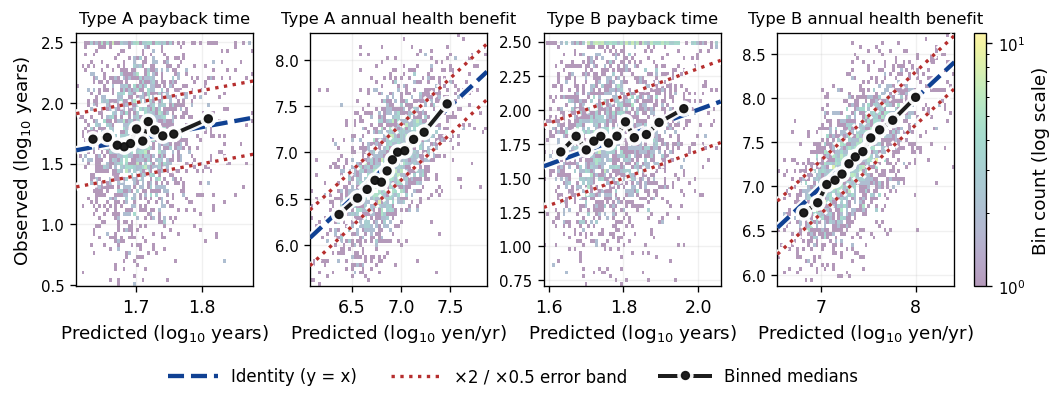

In [62]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# =========================
# I/O
# =========================
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
IN_CSV  = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear_contcal.csv")

EPS = 1e-12
CAP_YEARS = 300.0

TITLE_SCALE = 0.82   # ✅ 标题缩小到原来的 90%
YTICK_SCALE = 0.82   # ✅ y轴刻度数字缩小到原来的 88%

# =========================
# ✅ 一键调字号 / 版式（你主要改这里）
# =========================
FONT_SCALE = 1.00   # ✅ 整体字号缩放：0.8 更小，1.2 更大
FIGSIZE = (8.27, 3.4)  # ✅ 以“竖向A4页面宽度(8.27in)”为基准；高度可加大到 5.0~6.0 更清楚

# 画布留白（避免底部总图例挤压）
BOTTOM_FOR_LEGEND = 0.3 # ✅ 越大底部留白越多
RIGHT_FOR_CBAR = 0.035     # ✅ 右侧留给单独一个 colorbar

# =========================
# Styling (Nature Cities-ish)
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11 * FONT_SCALE,
    "axes.titlesize": 12 * FONT_SCALE * TITLE_SCALE,
    "ytick.labelsize": 11 * FONT_SCALE * YTICK_SCALE,   # ✅ 新增：y轴刻度更小
    "xtick.labelsize": 11 * FONT_SCALE * 0.95,          # 可选：x轴也略小一点更协调

    "axes.labelsize": 11 * FONT_SCALE,
    "legend.fontsize": 10 * FONT_SCALE,
})

# 彩色但“蒙白”淡化
BASE_CMAP_NAME = "viridis"
WHITEN = 0.58          # 0.50~0.65：越大越淡
DENSITY_ALPHA = 0.95

def make_pastel_cmap(name="viridis", whiten=0.58):
    cmap = plt.get_cmap(name)
    colors = cmap(np.linspace(0, 1, 256))
    colors[:, :3] = (1 - whiten) * colors[:, :3] + whiten * 1.0
    return ListedColormap(colors, name=f"{name}_pastel_w{whiten:.2f}")

PASTEL_CMAP = make_pastel_cmap(BASE_CMAP_NAME, WHITEN)

# 线条：高对比 + 白描边（保证压任何底色都清楚）
EFF = [pe.Stroke(linewidth=5.2 * FONT_SCALE, foreground="white", alpha=0.95), pe.Normal()]
LINE_ID = dict(color="#0b3d91", linestyle="--", linewidth=2.6 * FONT_SCALE, alpha=0.98, zorder=7)
LINE_B  = dict(color="#b22222", linestyle=":",  linewidth=2.0 * FONT_SCALE, alpha=0.95, zorder=7)
CAL_LN  = dict(color="#111111", linewidth=2.4 * FONT_SCALE, marker="o",
               markersize=4.6 * FONT_SCALE, alpha=0.95, zorder=8)

# =========================
# Helpers
# =========================
def _to_num(s):
    return pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)

def prep_xy(df, xcol, ycol, cap=None):
    x = _to_num(df[xcol]); y = _to_num(df[ycol])
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if cap is not None:
        x = np.clip(x, EPS, cap)
        y = np.clip(y, EPS, cap)
    return x, y

def quantile_window(lx, ly, qlo=0.01, qhi=0.99, pad=0.05):
    xlo, xhi = np.quantile(lx, qlo), np.quantile(lx, qhi)
    ylo, yhi = np.quantile(ly, qlo), np.quantile(ly, qhi)
    dx = (xhi - xlo) * pad
    dy = (yhi - ylo) * pad
    return (xlo - dx, xhi + dx, ylo - dy, yhi + dy)

def draw_ref_lines(ax, lo, hi):
    xx = np.linspace(lo, hi, 320)
    l1, = ax.plot(xx, xx, **LINE_ID)
    l2, = ax.plot(xx, xx + np.log10(2), **LINE_B)
    l3, = ax.plot(xx, xx - np.log10(2), **LINE_B)
    for ln in (l1, l2, l3):
        ln.set_path_effects(EFF)

def calibration_curve(lx, ly, q=12):
    lx = np.asarray(lx); ly = np.asarray(ly)
    if lx.size < 30:
        return pd.DataFrame({"lx_med": [], "ly_med": []})
    # 样本太少时自动降 q，避免 qcut 报错
    q_eff = int(min(q, max(4, lx.size // 10)))
    bins = pd.qcut(lx, q=q_eff, duplicates="drop")
    cal = (
        pd.DataFrame({"lx": lx, "ly": ly, "bin": bins})
        .groupby("bin")
        .agg(lx_med=("lx","median"), ly_med=("ly","median"), n=("lx","size"))
        .reset_index(drop=True)
        .sort_values("lx_med")
    )
    return cal

def compute_hist2d_counts(lx, ly, bins=65, rng=None):
    # rng: [[xlo,xhi],[ylo,yhi]]
    H, xedges, yedges = np.histogram2d(lx, ly, bins=bins, range=rng)
    return H

def plot_panel(ax, lx, ly, rng, bins, norm):
    # 密度底图
    h = ax.hist2d(
        lx, ly,
        bins=bins,
        range=rng,
        norm=norm,
        cmap=PASTEL_CMAP,
        alpha=DENSITY_ALPHA
    )
    # 参考线 & 校准
    xlo, xhi = rng[0]
    ylo, yhi = rng[1]
    lo = max(xlo, ylo)
    hi = min(xhi, yhi)
    draw_ref_lines(ax, lo, hi)

    cal = calibration_curve(lx, ly, q=12)
    if len(cal) > 0:
        ln, = ax.plot(cal["lx_med"], cal["ly_med"], **CAL_LN)
        ln.set_path_effects(EFF)

    ax.set_xlim(rng[0])
    ax.set_ylim(rng[1])
    ax.grid(True, alpha=0.18)
    return h[3]  # mappable for colorbar

# =========================
# Load
# =========================
df = pd.read_csv(IN_CSV, encoding="utf-8-sig")
df = df[df["abcde"].isin(["A","B"])].copy()

must = ["abcde", "payback_years", "payback_hat_contcal_years"]
miss = [c for c in must if c not in df.columns]
if miss:
    raise KeyError(f"Missing columns for payback: {miss}")

has_benefit = ("annual_benefit_yen" in df.columns) and ("benefit_hat_contcal_yen" in df.columns)
if not has_benefit:
    raise KeyError("需要 4 个图的话：缺少 annual_benefit_yen 或 benefit_hat_contcal_yen。")

# =========================
# Prepare 4 panels data
# =========================
PANELS = [
    ("A", "payback", "payback_hat_contcal_years", "payback_years", CAP_YEARS,
     "Type A payback time", "Predicted (log$_{10}$ years)", "Observed (log$_{10}$ years)"),
    ("A", "benefit", "benefit_hat_contcal_yen", "annual_benefit_yen", None,
     "Type A annual health benefit", "Predicted (log$_{10}$ yen/yr)", "Observed (log$_{10}$ yen/yr)"),
    ("B", "payback", "payback_hat_contcal_years", "payback_years", CAP_YEARS,
     "Type B payback time", "Predicted (log$_{10}$ years)", "Observed (log$_{10}$ years)"),
    ("B", "benefit", "benefit_hat_contcal_yen", "annual_benefit_yen", None,
     "Type B annual health benefit", "Predicted (log$_{10}$ yen/yr)", "Observed (log$_{10}$ yen/yr)"),
]

bins = 65

panel_data = []
global_vmax = 1

for (t, kind, xcol, ycol, cap, title, xlabel, ylabel) in PANELS:
    df_t = df[df["abcde"] == t].copy()
    x, y = prep_xy(df_t, xcol, ycol, cap=cap)
    lx = np.log10(x); ly = np.log10(y)
    xlo, xhi, ylo, yhi = quantile_window(lx, ly, 0.01, 0.99, pad=0.05)
    rng = [[xlo, xhi], [ylo, yhi]]

    H = compute_hist2d_counts(lx, ly, bins=bins, rng=rng)
    vmax = int(np.nanmax(H)) if H.size else 1
    global_vmax = max(global_vmax, vmax)

    panel_data.append((lx, ly, rng, title, xlabel, ylabel))

# 共享颜色刻度（所有子图一个 norm + 一个 colorbar）
shared_norm = LogNorm(vmin=1, vmax=max(1, global_vmax))

# =========================
# Plot 1×4 (one row)
# =========================
fig, axs = plt.subplots(1, 4, figsize=FIGSIZE, constrained_layout=False)

# 预留：底部总图例 + 右侧单个 colorbar
fig.subplots_adjust(
    left=0.06,
    right=1.0 - RIGHT_FOR_CBAR - 0.02,
    top=0.92,
    bottom=BOTTOM_FOR_LEGEND,
    wspace=0.32
)

last_mappable = None
for i, (ax, (lx, ly, rng, title, xlabel, ylabel)) in enumerate(zip(axs, panel_data)):
    last_mappable = plot_panel(ax, lx, ly, rng, bins=bins, norm=shared_norm)
    ax.set_title(title)

    # 轴标签：为了不拥挤，只给最左边一个 y 标签（你想每个都有也行）
    ax.set_xlabel(xlabel)
    if i == 0:
        ax.set_ylabel(ylabel)
    else:
        ax.set_ylabel("")

# =========================
# ✅ 全局 colorbar（只一个）
# =========================
cax = fig.add_axes([1.0 - RIGHT_FOR_CBAR, BOTTOM_FOR_LEGEND, 0.012, 0.92 - BOTTOM_FOR_LEGEND])
cb = fig.colorbar(last_mappable, cax=cax)
cb.set_label("Bin count (log scale)")

# =========================
# ✅ 底部全局图例（只有一行）
# =========================
legend_handles = [
    Line2D([0],[0], **LINE_ID, label="Identity (y = x)"),
    Line2D([0],[0], **LINE_B,  label="×2 / ×0.5 error band"),
    Line2D([0],[0], **CAL_LN,  label="Binned medians"),
]
# path effects 让图例线条也清晰
for h in legend_handles:
    h.set_path_effects(EFF)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
    handlelength=3.0
)

# =========================
# Save
# =========================
out_png = os.path.join(OUT_DIR, "fig_R3_AB_4panel_row.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print("Saved:", out_png)

plt.show()
plt.close(fig)


/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/1524339131.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")


Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/fig_R3_A_payback_density+calibration.png


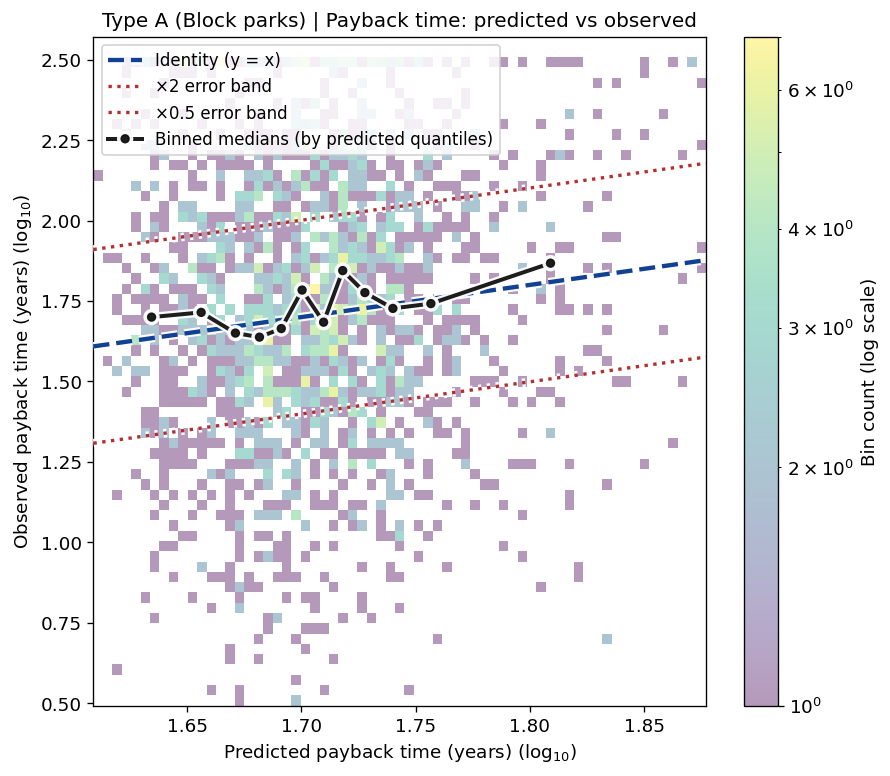

/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/1524339131.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")


Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/fig_R3_A_benefit_density+calibration.png


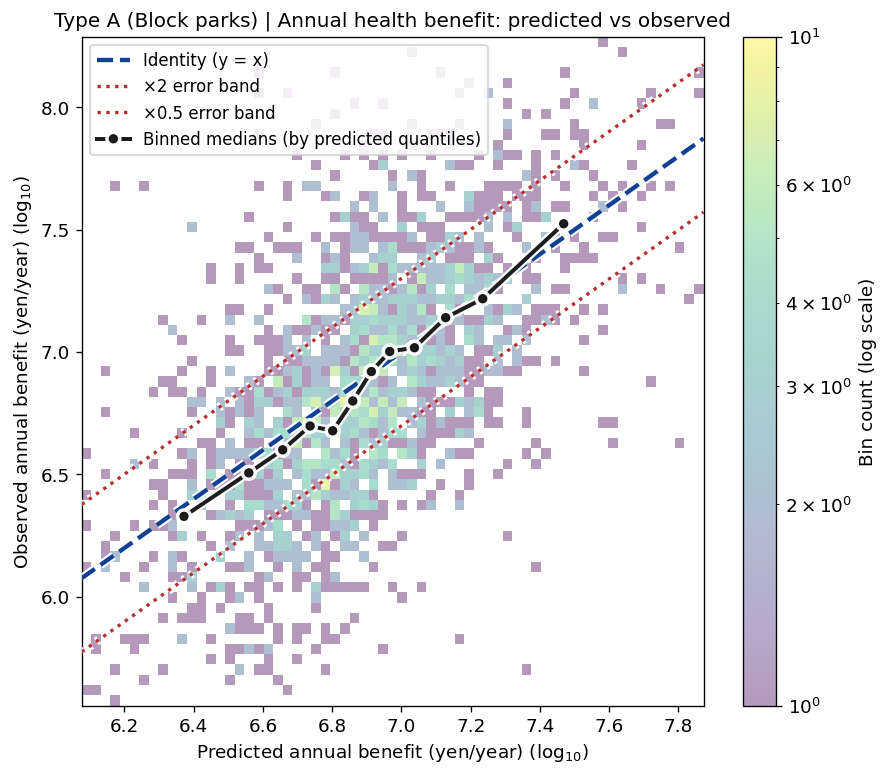

/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/1524339131.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")


Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/fig_R3_B_payback_density+calibration.png


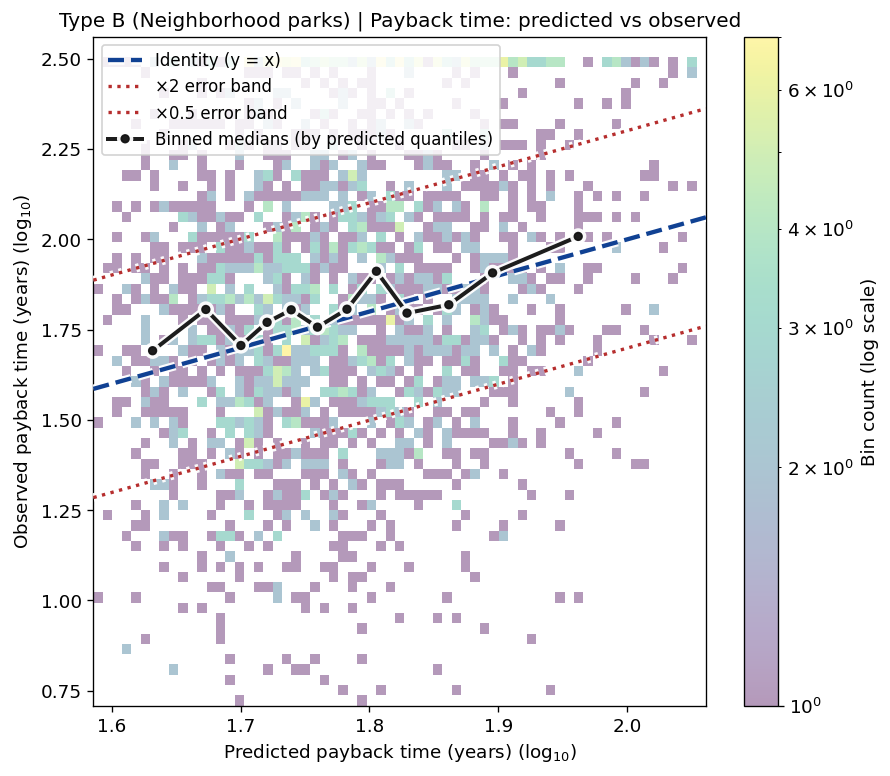

/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/1524339131.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("bin")


Saved: /Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/fig_R3_B_benefit_density+calibration.png


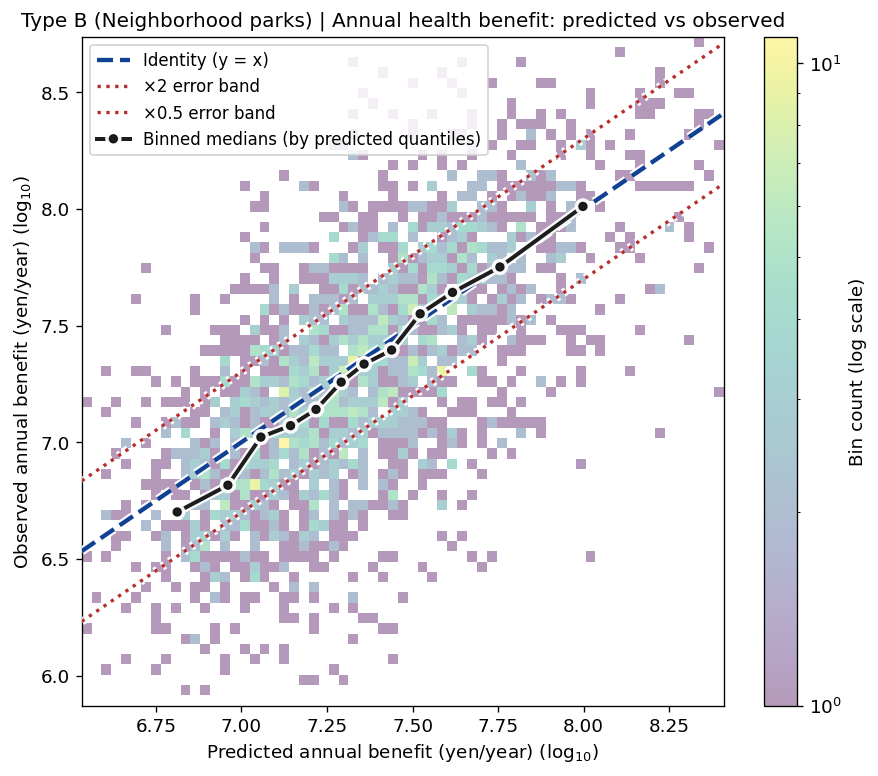

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
import matplotlib.patheffects as pe

# =========================
# I/O
# =========================
OUT_DIR = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output"
IN_CSV  = os.path.join(OUT_DIR, "park_result3_AB_twostep_payback_hat_smear_contcal.csv")

EPS = 1e-12
CAP_YEARS = 300.0

# =========================
# Styling (Nature Cities-ish)
# =========================
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# 彩色但“蒙白”淡化
BASE_CMAP_NAME = "viridis"
WHITEN = 0.58          # 0.50~0.65 调：越大越淡
DENSITY_ALPHA = 0.95

def make_pastel_cmap(name="viridis", whiten=0.58):
    cmap = plt.get_cmap(name)
    colors = cmap(np.linspace(0, 1, 256))
    colors[:, :3] = (1 - whiten) * colors[:, :3] + whiten * 1.0
    return ListedColormap(colors, name=f"{name}_pastel_w{whiten:.2f}")

PASTEL_CMAP = make_pastel_cmap(BASE_CMAP_NAME, WHITEN)

# 线条：高对比 + 白描边（保证压任何底色都清楚）
EFF = [pe.Stroke(linewidth=5.2, foreground="white", alpha=0.95), pe.Normal()]
LINE_ID = dict(color="#0b3d91", linestyle="--", linewidth=2.6, alpha=0.98, zorder=7)  # 深蓝
LINE_B  = dict(color="#b22222", linestyle=":",  linewidth=2.0, alpha=0.95, zorder=7)  # 暗红
CAL_LN  = dict(color="#111111", linewidth=2.4, marker="o", markersize=4.6, alpha=0.95, zorder=8)

# =========================
# Helpers
# =========================
def _to_num(s):
    return pd.to_numeric(s, errors="coerce").to_numpy(dtype=float)

def prep_xy(df, xcol, ycol, cap=None):
    x = _to_num(df[xcol]); y = _to_num(df[ycol])
    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[m]; y = y[m]
    if cap is not None:
        x = np.clip(x, EPS, cap)
        y = np.clip(y, EPS, cap)
    return x, y

def quantile_window(lx, ly, qlo=0.01, qhi=0.99, pad=0.05):
    xlo, xhi = np.quantile(lx, qlo), np.quantile(lx, qhi)
    ylo, yhi = np.quantile(ly, qlo), np.quantile(ly, qhi)
    dx = (xhi - xlo) * pad
    dy = (yhi - ylo) * pad
    return (xlo - dx, xhi + dx, ylo - dy, yhi + dy)

def draw_ref_lines(ax, lo, hi):
    xx = np.linspace(lo, hi, 320)
    l1, = ax.plot(xx, xx, label="Identity (y = x)", **LINE_ID)
    l2, = ax.plot(xx, xx + np.log10(2), label="×2 error band", **LINE_B)
    l3, = ax.plot(xx, xx - np.log10(2), label="×0.5 error band", **LINE_B)
    for ln in (l1, l2, l3):
        ln.set_path_effects(EFF)

def calibration_curve(lx, ly, q=12):
    bins = pd.qcut(lx, q=q, duplicates="drop")
    cal = (
        pd.DataFrame({"lx": lx, "ly": ly, "bin": bins})
        .groupby("bin")
        .agg(lx_med=("lx","median"), ly_med=("ly","median"), n=("lx","size"))
        .reset_index(drop=True)
        .sort_values("lx_med")
    )
    return cal

def plot_single_type_density_plus_cal(
    df_t, type_label, metric_label,
    xcol, ycol,
    xlabel, ylabel,
    out_png,
    cap=None,
    bins=65,
    q=12
):
    """
    单类型（A 或 B）的一张图：log10 密度底图 + 分箱校准曲线 + 参考线
    """
    x, y = prep_xy(df_t, xcol, ycol, cap=cap)
    lx = np.log10(x); ly = np.log10(y)

    xlo, xhi, ylo, yhi = quantile_window(lx, ly, 0.01, 0.99, pad=0.05)

    fig, ax = plt.subplots(figsize=(7.6, 6.6))

    h = ax.hist2d(
        lx, ly,
        bins=bins,
        range=[[xlo, xhi], [ylo, yhi]],
        norm=LogNorm(vmin=1),
        cmap=PASTEL_CMAP,
        alpha=DENSITY_ALPHA
    )
    cb = fig.colorbar(h[3], ax=ax)
    cb.set_label("Bin count (log scale)")

    # 参考线（仅可见范围内）
    lo = max(xlo, ylo)
    hi = min(xhi, yhi)
    draw_ref_lines(ax, lo, hi)

    # 校准曲线（同一张图叠加）
    cal = calibration_curve(lx, ly, q=q)
    ln, = ax.plot(cal["lx_med"], cal["ly_med"], label="Binned medians (by predicted quantiles)", **CAL_LN)
    ln.set_path_effects(EFF)

    ax.set_xlabel(xlabel + " (log$_{10}$)")
    ax.set_ylabel(ylabel + " (log$_{10}$)")
    ax.set_title(f"{type_label} | {metric_label}: predicted vs observed")

    leg = ax.legend(loc="upper left", frameon=True)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_alpha(0.85)

    fig.tight_layout()
    fig.savefig(out_png)
    print("Saved:", out_png)
    plt.show()


# =========================
# Load
# =========================
df = pd.read_csv(IN_CSV, encoding="utf-8-sig")
df = df[df["abcde"].isin(["A","B"])].copy()

# 必要列检查
must = ["abcde", "payback_years", "payback_hat_contcal_years"]
miss = [c for c in must if c not in df.columns]
if miss:
    raise KeyError(f"Missing columns for payback: {miss}")

has_benefit = ("annual_benefit_yen" in df.columns) and ("benefit_hat_contcal_yen" in df.columns)
if not has_benefit:
    print("[Note] Benefit plots will be skipped: need annual_benefit_yen and benefit_hat_contcal_yen")

# =========================
# Plot 4 figures
# =========================
TYPE_INFO = {
    "A": "Type A (Block parks)",
    "B": "Type B (Neighborhood parks)"
}

for t in ["A", "B"]:
    df_t = df[df["abcde"] == t].copy()
    type_label = TYPE_INFO[t]

    # 1) Payback
    plot_single_type_density_plus_cal(
        df_t=df_t,
        type_label=type_label,
        metric_label="Payback time",
        xcol="payback_hat_contcal_years",
        ycol="payback_years",
        xlabel="Predicted payback time (years)",
        ylabel="Observed payback time (years)",
        out_png=os.path.join(OUT_DIR, f"fig_R3_{t}_payback_density+calibration.png"),
        cap=CAP_YEARS,
        bins=65,
        q=12
    )

    # 2) Benefit
    if has_benefit:
        plot_single_type_density_plus_cal(
            df_t=df_t,
            type_label=type_label,
            metric_label="Annual health benefit",
            xcol="benefit_hat_contcal_yen",
            ycol="annual_benefit_yen",
            xlabel="Predicted annual benefit (yen/year)",
            ylabel="Observed annual benefit (yen/year)",
            out_png=os.path.join(OUT_DIR, f"fig_R3_{t}_benefit_density+calibration.png"),
            cap=None,
            bins=65,
            q=12
        )


/var/folders/98/dxfywpxj3x5b43cvqj3dbh6m0000gn/T/ipykernel_48253/1501644308.py:145: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  base_geom = base.unary_union


[pop points] n=255 | pop sum(raw)=38,132,673.00
[projection CRS] EPSG:32654
[POP_SCALE] cur_pop=38,132,673.00 | target=43,000,000 | scale=1.1276
[pop sum(scaled)] 43,000,000.00
[maint ref] A median=225 | B median=225
[sum_w_existing] min/median/max: 39586.42812694781 586493.703071179 1986109.1824750768
[grid] total=130,410 | inside=64,252 | step=250m
[land price] finite share: 1.0
[land price] median (finite): 148000.0


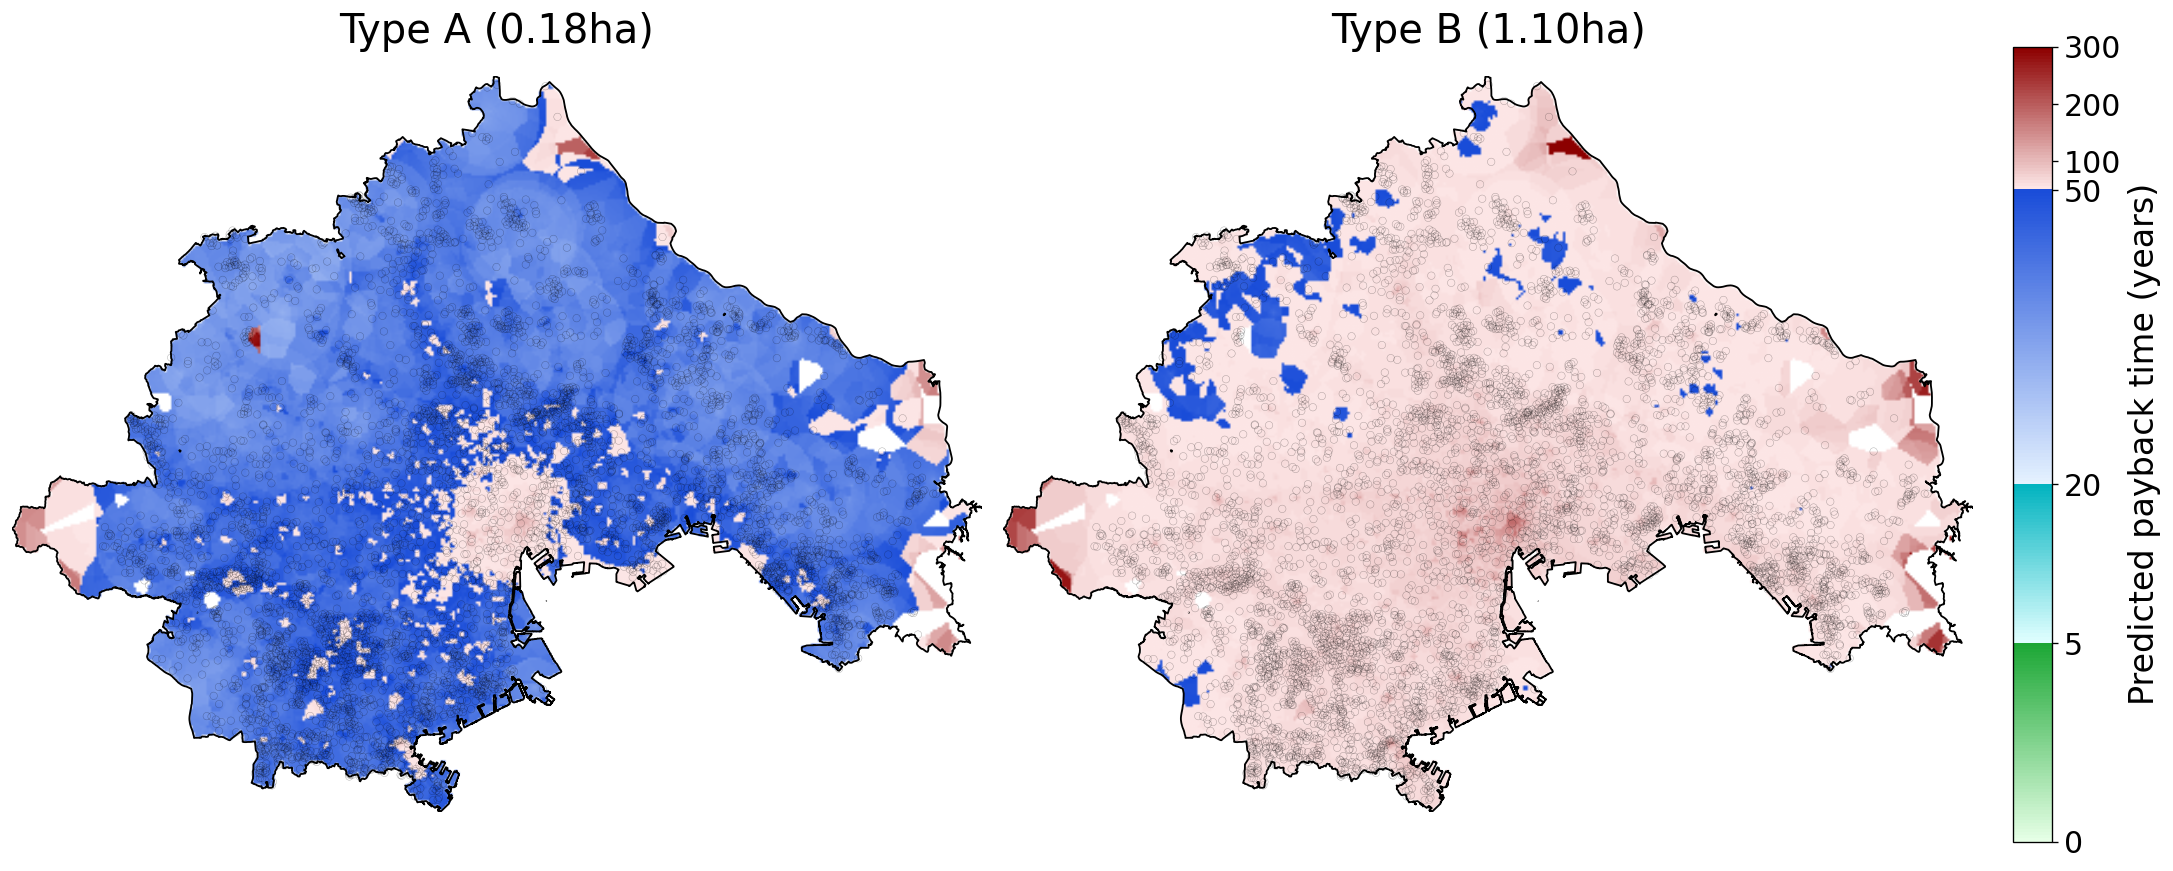


[Type A] finite share (inside grid) = 98.35% | NaN(white)=1.65%
  land-price missing (before fill+clean) within grid_in ≈ 0.00%

[Type B] finite share (inside grid) = 98.29% | NaN(white)=1.71%
  land-price missing (before fill+clean) within grid_in ≈ 0.00%

[feasibility among land-price-valid points]
  Type A: infeasible share ≈ 1.65%
  Type B: infeasible share ≈ 1.71%


In [64]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from matplotlib.colors import Normalize, LinearSegmentedColormap

# =========================
# ✅ GLOBAL FONT SCALE (×2)
# =========================
FONT_SCALE = 2.0
plt.rcParams.update({
    "font.size": 10 * FONT_SCALE,
    "axes.titlesize": 12 * FONT_SCALE,
    "axes.labelsize": 10 * FONT_SCALE,
    "xtick.labelsize": 9 * FONT_SCALE,
    "ytick.labelsize": 9 * FONT_SCALE,
})

# =========================
# 0) PATHS
# =========================
BASE_SHP = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/3_urbanpark_research_area/urbanpark_research_area.shp"
DID_SHP  = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/data/1_densityofpopulation/A16-15_00_DID.shp"
PARKS_CSV = r"/Users/suhang/Downloads/同步空间/工作文件/0-1博后论文/1.绿地_经济指标测算/program/output/park_payback_table.csv"
LANDPRICE_SHP = r"/Users/suhang/Downloads/L01-24_GML/L01-24.shp"

# =========================
# 1) CONTROLS
# =========================
GRID_STEP_M = 250
R_M = 6000.0
EPS = 1e-9
CAP_YEARS = 300.0

POP_COL = "A16_005"
DID_CRS_FALLBACK = "EPSG:6668"
LP_CRS_FALLBACK  = "EPSG:6668"
LP_VALUE_COL = "L01_008"   # confirmed land price (yen/m²)

# Hypothetical sizes
A_HA, B_HA = 0.18, 1.10
A_AREA_M2 = A_HA * 10_000.0
B_AREA_M2 = B_HA * 10_000.0

# Marker sizing: shrink to ~1/5 of current (based on your request)
MARKER_EXTRA_SHRINK = 0.20  # <- 1/5
S_MIN, S_MAX = 1.0, 20.0    # also cap smaller

# Colorbar compression (>50 shorter)
Y_5, Y_20, Y_50 = 0.25, 0.45, 0.82

# =========================
# 2) MODELS
# =========================
BENEFIT_PARAMS = {
    "A": dict(c=0.0313952, a_lp=0.8123, a_area=0.9647, a_epop=0.1073, a_maint=0.2503),
    "B": dict(c=0.3566980, a_lp=0.7719, a_area=0.7120, a_epop=0.0990, a_maint=0.2885),
}

PARAM_LOGESIGMA_BETA = {
    "A": (11.7571, -0.4160),
    "B": (11.9702, -0.4193),
    "C": (12.3210, -0.4217),
    "D": (12.2487, -0.3829),
    "E": (12.7412, -0.4308),
}
SIGMA = {k: float(np.exp(v[0])) for k, v in PARAM_LOGESIGMA_BETA.items()}
BETA  = {k: float(v[1]) for k, v in PARAM_LOGESIGMA_BETA.items()}

# =========================
# 3) HELPERS
# =========================
def safe_read_shp(path, columns_needed=None, crs_fallback=None):
    kwargs = {}
    if columns_needed is not None:
        kwargs["columns"] = columns_needed
    try:
        gdf = gpd.read_file(path, engine="pyogrio", **kwargs)
    except Exception as e1:
        print("[safe_read_shp] pyogrio failed -> fallback to fiona:", repr(e1))
        gdf = gpd.read_file(path, engine="fiona", **kwargs)
    if gdf.crs is None and crs_fallback is not None:
        gdf = gdf.set_crs(crs_fallback, allow_override=True)
    return gdf

class PiecewiseNorm(Normalize):
    def __init__(self, x, y, clip=False):
        super().__init__(vmin=min(x), vmax=max(x), clip=clip)
        self.x = np.asarray(x, float)
        self.y = np.asarray(y, float)
        if not (np.all(np.diff(self.x) > 0) and np.all(np.diff(self.y) > 0)):
            raise ValueError("x and y must be strictly increasing.")
    def __call__(self, value, clip=None):
        v = np.asarray(value, float)
        if (clip is True) or (self.clip is True):
            v = np.clip(v, self.vmin, self.vmax)
        return np.interp(v, self.x, self.y)
    def inverse(self, value):
        v = np.asarray(value, float)
        return np.interp(v, self.y, self.x)

def build_segment_cmap(y5=Y_5, y20=Y_20, y50=Y_50):
    stops = [
        (0.00, (0.90, 1.00, 0.90)),   # 0  very light green
        (y5,   (0.10, 0.65, 0.20)),   # 5  green

        (y5,   (0.88, 1.00, 1.00)),   # 5  light cyan
        (y20,  (0.00, 0.70, 0.75)),   # 20 cyan/teal

        (y20,  (0.90, 0.95, 1.00)),   # 20 light blue
        (y50,  (0.10, 0.30, 0.85)),   # 50 deep blue

        (y50,  (1.00, 0.92, 0.92)),   # 50 light red
        (1.00, (0.55, 0.00, 0.00)),   # 300 dark red
    ]
    return LinearSegmentedColormap.from_list("payback_piecewise", stops, N=256)

def robust_median_positive(s):
    s = pd.to_numeric(s, errors="coerce")
    s = s[np.isfinite(s) & (s > 0)]
    return float(np.median(s)) if len(s) else np.nan

def benefit_hat(type_letter, land_price, area_m2, epop, maint_yen_per_m2_yr):
    p = BENEFIT_PARAMS[type_letter]
    return (p["c"]
            * np.power(land_price, p["a_lp"])
            * np.power(area_m2, p["a_area"])
            * np.power(np.maximum(epop, 1.0), p["a_epop"])
            * np.power(maint_yen_per_m2_yr, p["a_maint"]))

def payback_hat(land_price, area_m2, benefit_yen_yr, maint_yen_per_m2_yr):
    land_cost = land_price * area_m2
    annual_maint = maint_yen_per_m2_yr * area_m2
    net = benefit_yen_yr - annual_maint
    T = np.full_like(net, np.nan, dtype=float)
    ok = net > EPS
    T[ok] = land_cost[ok] / net[ok]
    return np.clip(T, 0.0, CAP_YEARS), ok  # also return feasibility mask

# =========================
# 4) LOAD BASE + POP
# =========================
base = safe_read_shp(BASE_SHP, crs_fallback=DID_CRS_FALLBACK)
base_geom = base.unary_union

did = safe_read_shp(DID_SHP, columns_needed=[POP_COL], crs_fallback=DID_CRS_FALLBACK)
did = did.to_crs(base.crs)

did_clip = gpd.overlay(
    did,
    gpd.GeoDataFrame(geometry=[base_geom], crs=base.crs),
    how="intersection"
)
did_clip[POP_COL] = pd.to_numeric(did_clip[POP_COL], errors="coerce").fillna(0.0)
pop_pts = did_clip[did_clip[POP_COL] > 0].copy()
pop_pts["geometry"] = pop_pts.geometry.representative_point()

# UTM by centroid
base_ll = gpd.GeoSeries([base_geom], crs=base.crs).to_crs("EPSG:4326").iloc[0]
cent = base_ll.centroid
lon, lat = cent.x, cent.y
utm_zone = int((lon + 180) // 6) + 1
utm_epsg = 32600 + utm_zone if lat >= 0 else 32700 + utm_zone
PROJ_CRS = f"EPSG:{utm_epsg}"

base_m = gpd.GeoSeries([base_geom], crs=base.crs).to_crs(PROJ_CRS).iloc[0]
boundary = gpd.GeoSeries([base_m], crs=PROJ_CRS).boundary

pop_pts_m = pop_pts.to_crs(PROJ_CRS)
pop_xy = np.vstack([pop_pts_m.geometry.x.values, pop_pts_m.geometry.y.values]).T
pop_w  = pop_pts_m[POP_COL].values.astype(float)

print(f"[pop points] n={len(pop_pts_m)} | pop sum(raw)={pop_w.sum():,.2f}")
print("[projection CRS]", PROJ_CRS)

# =========================
# ✅ 4.5) POP SCALING (sample -> total)
# =========================
TARGET_TOTAL_POP = 43_000_000  # 4300万人（你认为的总体口径）
cur_pop = float(np.nansum(pop_w))
POP_SCALE = TARGET_TOTAL_POP / cur_pop if cur_pop > 0 else 1.0

print(f"[POP_SCALE] cur_pop={cur_pop:,.2f} | target={TARGET_TOTAL_POP:,.0f} | scale={POP_SCALE:.4f}")

# 应用放大（让后续 Epop、benefit 全部基于总人口口径）
pop_w = pop_w * POP_SCALE

print(f"[pop sum(scaled)] {float(np.nansum(pop_w)):,.2f}")


# =========================
# 5) LOAD PARKS (existing)
# =========================
parks = pd.read_csv(PARKS_CSV, encoding="utf-8-sig")

type_col = "park_class_name" if "park_class_name" in parks.columns else None
if type_col is None:
    raise KeyError("Cannot find park_class_name in PARKS_CSV.")
parks[type_col] = parks[type_col].astype(str).str.strip().str.upper()

name_to_abcde = {
    "CITY BLOCK PARK": "A",
    "BLOCK PARK": "A",
    "NEIGHBORHOOD PARK": "B",
    "DISTRICT PARK": "C",
    "COMPREHENSIVE PARK": "D",
    "REGIONAL PARK": "E",
}
parks["abcde"] = parks[type_col].map(name_to_abcde)

lon_candidates = [c for c in ["Lng","lon","longitude","Lon","LONG"] if c in parks.columns]
lat_candidates = [c for c in ["Lat","lat","latitude","LAT"] if c in parks.columns]
if not lon_candidates or not lat_candidates:
    raise KeyError("PARKS_CSV missing lon/lat columns.")
LON_COL, LAT_COL = lon_candidates[0], lat_candidates[0]

area_candidates = [c for c in ["area","Area m2","Area_m2","area_m2","Area m2 "] if c in parks.columns]
maint_candidates = [c for c in ["unit_maintenance_yen_per_m2_2024","unit_maintenance_yen_per_m2","maint_yen_per_m2","maint"] if c in parks.columns]
if not area_candidates or not maint_candidates:
    raise KeyError("PARKS_CSV missing area or maint intensity column.")
AREA_COL = area_candidates[0]
MAINT_COL = maint_candidates[0]

for c in [LON_COL, LAT_COL, AREA_COL, MAINT_COL]:
    parks[c] = pd.to_numeric(parks[c], errors="coerce")
parks = parks[np.isfinite(parks[LON_COL]) & np.isfinite(parks[LAT_COL])].copy()

gparks = gpd.GeoDataFrame(
    parks,
    geometry=gpd.points_from_xy(parks[LON_COL], parks[LAT_COL]),
    crs="EPSG:4326"
).to_crs(PROJ_CRS)

MAINT_A = robust_median_positive(gparks.loc[gparks["abcde"]=="A", MAINT_COL])
MAINT_B = robust_median_positive(gparks.loc[gparks["abcde"]=="B", MAINT_COL])
print(f"[maint ref] A median={MAINT_A:.4g} | B median={MAINT_B:.4g}")
if not (np.isfinite(MAINT_A) and np.isfinite(MAINT_B)):
    raise ValueError("MAINT_A/MAINT_B is NaN. Check MAINT_COL values for A/B in PARKS_CSV.")

park_xy = np.vstack([gparks.geometry.x.values, gparks.geometry.y.values]).T
park_type = gparks["abcde"].values.astype(object)

# =========================
# 6) COMPETITION SUM
# =========================
sigma_p = np.array([SIGMA.get(t, np.nan) for t in park_type], dtype=float)
beta_p  = np.array([BETA.get(t, np.nan)  for t in park_type], dtype=float)
okp = np.isfinite(sigma_p) & np.isfinite(beta_p)

park_xy2 = park_xy[okp]
sigma_p2 = sigma_p[okp]
beta_p2  = beta_p[okp]

dx = pop_xy[:, 0:1] - park_xy2[None, :, 0]
dy = pop_xy[:, 1:2] - park_xy2[None, :, 1]
dist = np.sqrt(dx*dx + dy*dy)

mask = dist <= R_M
dist_safe = np.maximum(dist, 1.0)

W = sigma_p2[None, :] * np.power(dist_safe, beta_p2[None, :])
W[~mask] = 0.0
sum_w_existing = W.sum(axis=1)

print("[sum_w_existing] min/median/max:",
      float(np.min(sum_w_existing)), float(np.median(sum_w_existing)), float(np.max(sum_w_existing)))

# =========================
# 7) GRID
# =========================
minx, miny, maxx, maxy = base_m.bounds
xs = np.arange(minx, maxx + GRID_STEP_M, GRID_STEP_M)
ys = np.arange(miny, maxy + GRID_STEP_M, GRID_STEP_M)
XX, YY = np.meshgrid(xs, ys)
grid_xy = np.vstack([XX.ravel(), YY.ravel()]).T

grid_gdf = gpd.GeoDataFrame(geometry=[Point(xy) for xy in grid_xy], crs=PROJ_CRS)
inside = grid_gdf.within(base_m).values
grid_in = grid_xy[inside]
grid_gdf_in = grid_gdf.loc[inside].copy()

print(f"[grid] total={len(grid_xy):,} | inside={len(grid_in):,} | step={GRID_STEP_M}m")

# =========================
# 8) LAND PRICE JOIN
# =========================
lp = safe_read_shp(LANDPRICE_SHP, crs_fallback=LP_CRS_FALLBACK).to_crs(PROJ_CRS)
if LP_VALUE_COL not in lp.columns:
    raise KeyError(f"LP_VALUE_COL={LP_VALUE_COL} not found in LANDPRICE_SHP.")
lp[LP_VALUE_COL] = pd.to_numeric(lp[LP_VALUE_COL], errors="coerce")

joined = gpd.sjoin(grid_gdf_in, lp[[LP_VALUE_COL, "geometry"]], how="left", predicate="within")
lp_grid = joined[LP_VALUE_COL].to_numpy(float)

miss = ~np.isfinite(lp_grid)
if miss.any():
    nearest = gpd.sjoin_nearest(grid_gdf_in.loc[miss], lp[[LP_VALUE_COL, "geometry"]], how="left")
    lp_grid[miss] = nearest[LP_VALUE_COL].to_numpy(float)

lp_grid = np.where(np.isfinite(lp_grid) & (lp_grid > 0), lp_grid, np.nan)
valid_lp = np.isfinite(lp_grid)

print("[land price] finite share:", float(np.mean(valid_lp)))
print("[land price] median (finite):", float(np.nanmedian(lp_grid)))

# =========================
# 9) EPOP FOR CANDIDATE
# =========================
def compute_epop(grid_in_xy, type_letter, chunk=6000):
    sig = SIGMA[type_letter]
    bet = BETA[type_letter]
    out = np.zeros(len(grid_in_xy), dtype=float)

    for s in range(0, len(grid_in_xy), chunk):
        e = min(len(grid_in_xy), s + chunk)
        g = grid_in_xy[s:e]

        dx = g[:, 0:1] - pop_xy[None, :, 0]
        dy = g[:, 1:2] - pop_xy[None, :, 1]
        d = np.sqrt(dx*dx + dy*dy)

        m = d <= R_M
        d_safe = np.maximum(d, 1.0)
        w_c = sig * np.power(d_safe, bet)
        w_c[~m] = 0.0

        denom = sum_w_existing[None, :] + w_c
        share = np.where(denom > 0, w_c / denom, 0.0)
        out[s:e] = (share * pop_w[None, :]).sum(axis=1)

    return out

Epop_A = compute_epop(grid_in, "A")
Epop_B = compute_epop(grid_in, "B")

# =========================
# 10) PAYBACK GRID
# =========================
TA = np.full(len(grid_in), np.nan, float)
TB = np.full(len(grid_in), np.nan, float)

benA = benefit_hat("A", lp_grid[valid_lp], A_AREA_M2, Epop_A[valid_lp], MAINT_A)
benB = benefit_hat("B", lp_grid[valid_lp], B_AREA_M2, Epop_B[valid_lp], MAINT_B)

TA_valid, okA = payback_hat(lp_grid[valid_lp], A_AREA_M2, benA, MAINT_A)
TB_valid, okB = payback_hat(lp_grid[valid_lp], B_AREA_M2, benB, MAINT_B)

TA[valid_lp] = TA_valid
TB[valid_lp] = TB_valid

# rasterize back
TA_full = np.full(len(grid_xy), np.nan, float)
TB_full = np.full(len(grid_xy), np.nan, float)
TA_full[inside] = TA
TB_full[inside] = TB

TA_img = TA_full.reshape(YY.shape)
TB_img = TB_full.reshape(YY.shape)

# =========================
# 11) COLOR
# =========================
NORM = PiecewiseNorm(
    x=[0, 5, 20, 50, 300],
    y=[0.00, Y_5, Y_20, Y_50, 1.00],
    clip=True
)
CMAP = build_segment_cmap(Y_5, Y_20, Y_50).copy()
CMAP.set_bad("white")

# =========================
# 12) EXISTING PARK MARKERS (smaller)
# =========================
area_vals = pd.to_numeric(gparks[AREA_COL], errors="coerce").to_numpy(float)
area_vals = np.where(np.isfinite(area_vals) & (area_vals > 0), area_vals, np.nan)

sqrtA = np.sqrt(area_vals)
s_raw = (sqrtA / 25.0)**2
s = np.clip(s_raw * 100.0 * MARKER_EXTRA_SHRINK, S_MIN, S_MAX)

# =========================
# 13) PLOT (no x/y axis)
# =========================
# =========================
# 13) PLOT (two maps in one row + single colorbar)
# =========================
def draw_map(ax, img, title):
    im = ax.imshow(
        img,
        origin="lower",
        extent=[minx, maxx, miny, maxy],
        cmap=CMAP,
        norm=NORM,
        interpolation="bilinear"
    )

    # boundary
    boundary.plot(ax=ax, linewidth=1.1, color="black")

    # existing parks as hollow circles (keep markers, remove the "Hollow circles..." text)
    ax.scatter(
        gparks.geometry.x.values,
        gparks.geometry.y.values,
        s=s,
        facecolors="none",
        edgecolors="black",
        linewidths=0.30,
        alpha=0.30,
        zorder=3
    )

    ax.set_title(title, pad=10 * FONT_SCALE)

    # map-like: no axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_axis_off()

    return im

# ✅ one figure, two panels (side-by-side)
fig, axs = plt.subplots(1, 2, figsize=(18.0, 7.2), constrained_layout=True)

im0 = draw_map(axs[0], TA_img, f"Type A ({A_HA:.2f}ha)")
im1 = draw_map(axs[1], TB_img, f"Type B ({B_HA:.2f}ha)")

# ✅ single shared colorbar
cb = fig.colorbar(im0, ax=axs, fraction=0.046, pad=0.02)
cb.set_label("Predicted payback time (years)", fontsize=10 * FONT_SCALE)
cb.set_ticks([0, 5, 20, 50, 100, 200, 300])
cb.ax.tick_params(labelsize=9 * FONT_SCALE)

plt.show()


# =========================
# 14) WHY WHITE AREAS? quick diagnostics
# =========================
def diagnose(arr, name):
    a = arr.copy()
    finite = np.isfinite(a)
    print(f"\n[{name}] finite share (inside grid) = {finite.mean()*100:.2f}% | NaN(white)={100 - finite.mean()*100:.2f}%")
    # a) land price missing
    # valid_lp corresponds to grid_in length; we can infer LP-missing share
    lp_missing = (~valid_lp).mean()*100
    print(f"  land-price missing (before fill+clean) within grid_in ≈ {lp_missing:.2f}%")
    # b) infeasible net benefit share (benefit <= maint)
    # ok mask only computed on valid_lp portion
    # we estimate infeasible among valid_lp points:
    # (note: this is per type, because okA/okB depends on benefit params & area & maint)
    return

diagnose(TA, "Type A")
diagnose(TB, "Type B")

# If you want deeper: count infeasible (benefit - maint*area <=0)
# (computed on valid_lp points)
print("\n[feasibility among land-price-valid points]")
print(f"  Type A: infeasible share ≈ {(1.0 - okA.mean())*100:.2f}%")
print(f"  Type B: infeasible share ≈ {(1.0 - okB.mean())*100:.2f}%")


In [53]:
# =========================
# 15) AREA SHARE BY PAYBACK BINS (for paper)
# =========================
def area_share_report(T_vec, grid_step_m, name):
    """
    T_vec: length = len(grid_in) payback values for inside-grid points (NaN allowed)
    """
    T = np.asarray(T_vec, float)
    cell_area = (grid_step_m ** 2)  # m² per grid cell

    total_cells = len(T)
    total_area = total_cells * cell_area

    finite = np.isfinite(T)
    nan_cells = np.sum(~finite)

    # bins
    b0 = np.sum(finite & (T >= 0)  & (T < 5))
    b1 = np.sum(finite & (T >= 5)  & (T < 20))
    b2 = np.sum(finite & (T >= 20) & (T <= 50))
    b3 = np.sum(finite & (T > 50))   # includes cap=300, etc.

    def pct(n): 
        return 100.0 * (n * cell_area) / total_area

    print(f"\n[{name}] Area shares (grid step={grid_step_m} m; cell={cell_area:,.0f} m²)")
    print(f"  0–5 years     : {pct(b0):6.2f}%")
    print(f"  5–20 years    : {pct(b1):6.2f}%")
    print(f"  20–50 years   : {pct(b2):6.2f}%")
    print(f"  >50 years     : {pct(b3):6.2f}%")
    print(f"  NaN (white)   : {pct(nan_cells):6.2f}%")
    print(f"  (check sum)   : {pct(b0+b1+b2+b3+nan_cells):6.2f}%")

# TA and TB in your code are vectors aligned with grid_in (inside points)
area_share_report(TA, GRID_STEP_M, f"Type A ({A_HA:.2f} ha)")
area_share_report(TB, GRID_STEP_M, f"Type B ({B_HA:.2f} ha)")



[Type A (0.18 ha)] Area shares (grid step=250 m; cell=62,500 m²)
  0–5 years     :   0.00%
  5–20 years    :   0.00%
  20–50 years   :  85.35%
  >50 years     :  13.00%
  NaN (white)   :   1.65%
  (check sum)   : 100.00%

[Type B (1.10 ha)] Area shares (grid step=250 m; cell=62,500 m²)
  0–5 years     :   0.00%
  5–20 years    :   0.00%
  20–50 years   :   3.63%
  >50 years     :  94.66%
  NaN (white)   :   1.71%
  (check sum)   : 100.00%


=== Baseline shares in C0 = area*(land_price + kcon) ===
s_land = land_price/(land_price+kcon) = 0.800000
s_kcon = kcon/(land_price+kcon)       = 0.200000

=== Elasticities: d ln T / d ln X (baseline) ===
Type   Variable  elasticity_dlnT_dlnX
   A       Epop               -0.1073
   A      maint               -0.2503
   A       area                0.0353
   A land_price               -0.0123
   A       kcon                0.2000
   B       Epop               -0.0990
   B      maint               -0.2885
   B       area                0.2880
   B land_price                0.0281
   B       kcon                0.2000

=== Sensitivity dataframe (head) ===
Type   Variable  delta  delta_pct  pct_change_T_exact  pct_change_T_elastic
   A land_price 0.0000       0.00            0.000000              0.000000
   A land_price 0.0025       0.25           -0.003021             -0.003071
   A land_price 0.0050       0.50           -0.005936             -0.006134
   A land_price 0.0075       0.75  

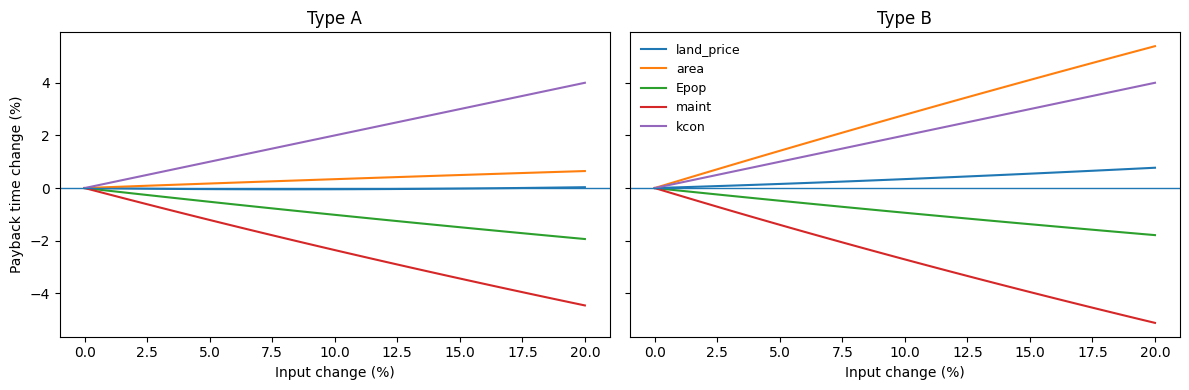

 - payback_sensitivity_0_20_solid.png


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) Hard-coded parameters (your Table)
#    注意：你表里写的是 C0，但在收益式(1)里是 Ct（比例系数）。
#    这里我们用 Ct 作为收益系数，避免和成本 C0 混淆。
# ============================================================
PARAMS = {
    "A": {"Ct": 0.0313952, "b1": 0.8123, "b2": 0.9647, "b3": 0.1073, "b4": 0.2503},
    "B": {"Ct": 0.3566980, "b1": 0.7719, "b2": 0.7120, "b3": 0.0990, "b4": 0.2885},
}

# ============================================================
# 2) Baseline inputs (写死，但你可以在这里改成更贴近你研究的量级)
#    land_price 与 kcon 的“相对大小”决定 land share，从而影响 land_price 的净弹性
# ============================================================
BASE = {
    "land_price": 4.0,  # baseline land price (must be > 0)
    "kcon": 1.0,        # baseline construction unit cost (must be > 0)
    "area": 1.0,        # must be > 0
    "Epop": 1.0,        # must be > 0
    "maint": 1.0,       # must be > 0
}

# ============================================================
# 3) Model definitions
#    B_t = Ct * land_price^b1 * area^b2 * Epop^b3 * maint^b4
#    C0  = area * (land_price + kcon)
#    T   = C0 / B_t
# ============================================================
def B_t(t, land_price, area, Epop, maint):
    p = PARAMS[t]
    return (
        p["Ct"]
        * (land_price ** p["b1"])
        * (area ** p["b2"])
        * (Epop ** p["b3"])
        * (maint ** p["b4"])
    )

def C0(area, land_price, kcon):
    return area * (land_price + kcon)

def T_payback(t, land_price, area, Epop, maint, kcon):
    return C0(area, land_price, kcon) / B_t(t, land_price, area, Epop, maint)

# ============================================================
# 4) Elasticities at baseline (d ln T / d ln X)
# ============================================================
def elasticities_at_baseline():
    lp0 = BASE["land_price"]
    kc0 = BASE["kcon"]
    s_land = lp0 / (lp0 + kc0)
    s_kcon = kc0 / (lp0 + kc0)

    rows = []
    for t in ["A", "B"]:
        p = PARAMS[t]
        rows.append([t, "Epop",       -p["b3"]])
        rows.append([t, "maint",      -p["b4"]])
        rows.append([t, "area",       1.0 - p["b2"]])
        rows.append([t, "land_price", s_land - p["b1"]])
        rows.append([t, "kcon",       s_kcon])  # 对 ln(kcon) 的弹性（小扰动下解释合理）

    elast = pd.DataFrame(rows, columns=["Type", "Variable", "elasticity_dlnT_dlnX"])
    return elast, s_land, s_kcon

# ============================================================
# 5) Sensitivity curves: delta from 0% to +20% (one-at-a-time)
# ============================================================
def run_sensitivity(dmin=0.0, dmax=0.20, n=81):
    if dmin < 0:
        raise ValueError("This version is for dmin >= 0 (0% to +20%).")
    deltas = np.linspace(dmin, dmax, n)
    variables = ["land_price", "area", "Epop", "maint", "kcon"]

    lp0, a0, e0, m0, kc0 = (BASE["land_price"], BASE["area"], BASE["Epop"], BASE["maint"], BASE["kcon"])
    if min(lp0, a0, e0, m0, kc0) <= 0:
        raise ValueError("All BASE values must be > 0.")

    elast, _, _ = elasticities_at_baseline()
    elast_map = {(r["Type"], r["Variable"]): r["elasticity_dlnT_dlnX"] for _, r in elast.iterrows()}

    records = []
    for t in ["A", "B"]:
        T0 = T_payback(t, lp0, a0, e0, m0, kc0)

        for var in variables:
            e_elast = elast_map[(t, var)]
            for d in deltas:
                # one-at-a-time perturbation
                lp = lp0 * (1.0 + d) if var == "land_price" else lp0
                a  = a0  * (1.0 + d) if var == "area"       else a0
                ep = e0  * (1.0 + d) if var == "Epop"       else e0
                ma = m0  * (1.0 + d) if var == "maint"      else m0
                kc = kc0 * (1.0 + d) if var == "kcon"       else kc0

                T1 = T_payback(t, lp, a, ep, ma, kc)
                pct_exact = (T1 / T0 - 1.0) * 100.0

                # optional: elasticity approximation (kept in output for diagnostics; not plotted)
                pct_elastic = (np.exp(e_elast * np.log(1.0 + d)) - 1.0) * 100.0

                records.append({
                    "Type": t,
                    "Variable": var,
                    "delta": d,
                    "delta_pct": d * 100.0,
                    "pct_change_T_exact": pct_exact,
                    "pct_change_T_elastic": pct_elastic,
                })

    return pd.DataFrame(records), elast

# ============================================================
# 6) Plot: one figure, 2 panels (Type A / Type B) - SOLID ONLY
# ============================================================
def plot_sensitivity(df, out_png="payback_sensitivity_0_20_solid.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    order = ["land_price", "area", "Epop", "maint", "kcon"]

    for ax, t in zip(axes, ["A", "B"]):
        sub = df[df["Type"] == t]
        for var in order:
            tmp = sub[sub["Variable"] == var].sort_values("delta")
            ax.plot(tmp["delta_pct"], tmp["pct_change_T_exact"], label=var)  # ✅ only solid exact lines

        ax.axhline(0, linewidth=1)
        ax.set_title(f"Type {t}")
        ax.set_xlabel("Input change (%)")

    axes[0].set_ylabel("Payback time change (%)")
    axes[1].legend(frameon=False, fontsize=9)

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================
# 7) EXECUTE (this is what you were missing!)
# ============================================================
if __name__ == "__main__":
    elast, s_land, s_kcon = elasticities_at_baseline()
    print("=== Baseline shares in C0 = area*(land_price + kcon) ===")
    print(f"s_land = land_price/(land_price+kcon) = {s_land:.6f}")
    print(f"s_kcon = kcon/(land_price+kcon)       = {s_kcon:.6f}\n")

    print("=== Elasticities: d ln T / d ln X (baseline) ===")
    print(elast.to_string(index=False))
    print()

    df, _ = run_sensitivity(dmin=0.0, dmax=0.20, n=81)

    # save outputs
    elast.to_csv("payback_elasticities.csv", index=False)
    df.to_csv("payback_sensitivity_curves_0_20.csv", index=False)

    # quick sanity check
    print("=== Sensitivity dataframe (head) ===")
    print(df.head(10).to_string(index=False))
    print("\nSaved files:")
    print(" - payback_elasticities.csv")
    print(" - payback_sensitivity_curves_0_20.csv")

    # plot
    plot_sensitivity(df, out_png="payback_sensitivity_0_20_solid.png")
    print(" - payback_sensitivity_0_20_solid.png")
